<a href="https://colab.research.google.com/github/rafiatoumalamali-cell/lab-3/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Rafiatou Malam Ali
**Student ID:** 30782027

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

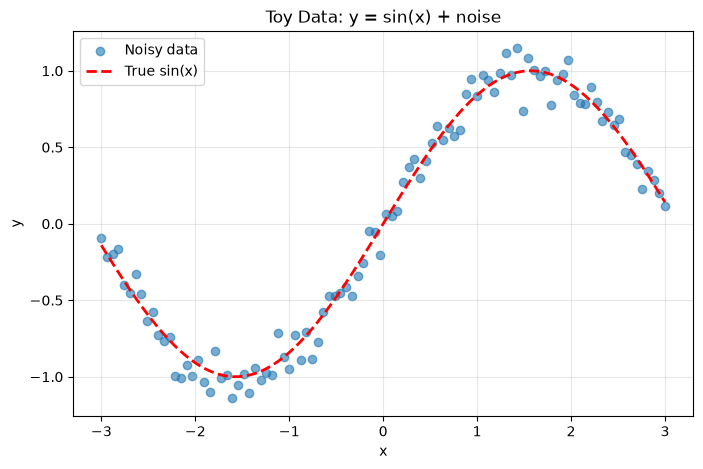

Initial w: 0.2484, b: -0.0691
Step   0, Loss: 0.224068, w: 0.3039, b: -0.0574
Step  20, Loss: 0.195452, w: 0.3390, b: -0.0109
Step  40, Loss: 0.195452, w: 0.3390, b: -0.0104
Step  60, Loss: 0.195452, w: 0.3390, b: -0.0104
Step  80, Loss: 0.195452, w: 0.3390, b: -0.0104
Step 100, Loss: 0.195452, w: 0.3390, b: -0.0104
Step 120, Loss: 0.195452, w: 0.3390, b: -0.0104
Step 140, Loss: 0.195452, w: 0.3390, b: -0.0104
Step 160, Loss: 0.195452, w: 0.3390, b: -0.0104
Step 180, Loss: 0.195452, w: 0.3390, b: -0.0104


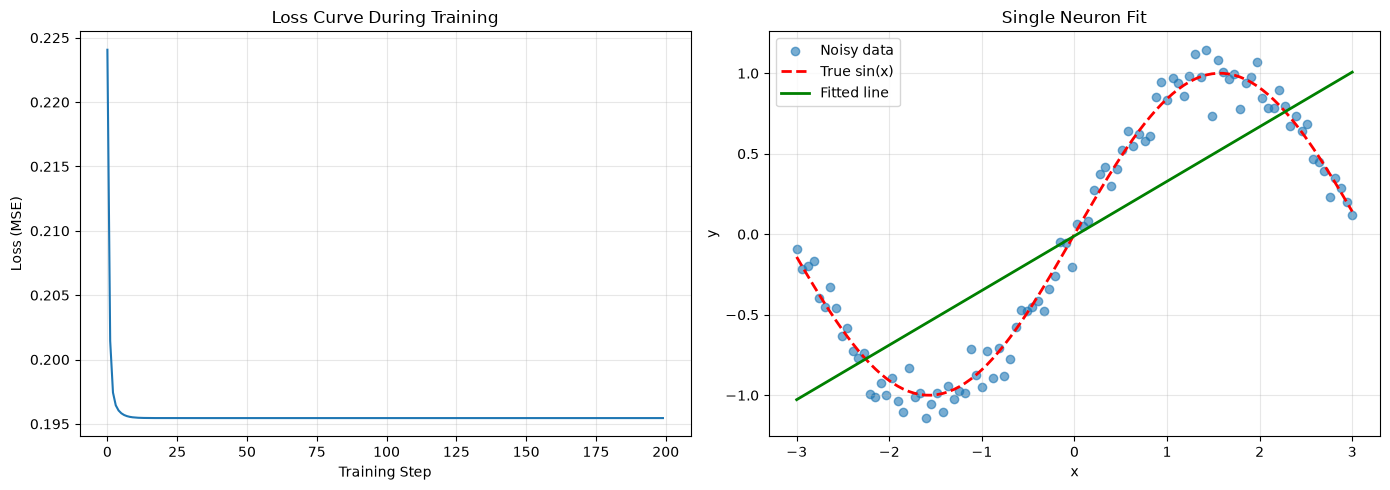


Final w: 0.3390, b: -0.0104
Final loss: 0.195452


In [2]:
# TODO 1: Generate the toy data
x = np.linspace(-3, 3, 100)
noise = np.random.randn(100) * 0.1
y = np.sin(x) + noise

# Plot the data
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.6, label="Noisy data")
plt.plot(x, np.sin(x), "r--", label="True sin(x)", linewidth=2)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Toy Data: y = sin(x) + noise")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# TODO 2: Initialise w and b to small random values.
np.random.seed(42)  # For reproducible results
w = np.random.randn() * 0.5  # Random weight
b = np.random.randn() * 0.5  # Random bias
lr = 0.1  # Learning rate
loss_history = []  # To store loss at each step
print(f"Initial w: {w:.4f}, b: {b:.4f}")

# TODO 3: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
for step in range(200):
    # Forward pass: compute predictions
    y_hat = w * x + b

    # Compute loss (Mean Squared Error)
    loss = np.mean((y_hat - y) ** 2)
    loss_history.append(loss)  # Record loss

    # Compute gradients (backward pass)
    dw = np.mean(2 * (y_hat - y) * x)  # dLoss/dw
    db = np.mean(2 * (y_hat - y))  # dLoss/db

    # Update parameters
    w = w - lr * dw
    b = b - lr * db

    # Print progress every 20 steps
    if step % 20 == 0:
        print(f"Step {step:3d}, Loss: {loss:.6f}, w: {w:.4f}, b: {b:.4f}")

# TODO 4: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot (a): Loss curve
ax1.plot(loss_history)
ax1.set_xlabel("Training Step")
ax1.set_ylabel("Loss (MSE)")
ax1.set_title("Loss Curve During Training")
ax1.grid(True, alpha=0.3)

# Plot (b): Data with fitted line
ax2.scatter(x, y, alpha=0.6, label="Noisy data")
ax2.plot(x, np.sin(x), "r--", label="True sin(x)", linewidth=2)
ax2.plot(x, w * x + b, "g-", label="Fitted line", linewidth=2)
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_title("Single Neuron Fit")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal w: {w:.4f}, b: {b:.4f}")
print(f"Final loss: {loss_history[-1]:.6f}")


**Student Reasoning — The single neuron**
> **Answer:**

**Student Reasoning — The single neuron**

### 1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match the code?

**Derivation using LaTeX:**

Loss function (Mean Squared Error):

$$L = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$

Where $\hat{y}_i = w x_i + b$

To find $\frac{dL}{dw}$, we use the chain rule:

$$\frac{dL}{dw} = \frac{1}{n} \sum_{i=1}^{n} \frac{d}{dw}(\hat{y}_i - y_i)^2$$

$$\frac{dL}{dw} = \frac{1}{n} \sum_{i=1}^{n} 2(\hat{y}_i - y_i) \cdot \frac{d\hat{y}_i}{dw}$$

Since $\hat{y}_i = w x_i + b$, we have $\frac{d\hat{y}_i}{dw} = x_i$

$$\frac{dL}{dw} = \frac{1}{n} \sum_{i=1}^{n} 2(\hat{y}_i - y_i) \cdot x_i$$

$$\frac{dL}{dw} = \text{mean}(2(\hat{y} - y) \cdot x)$$

**This matches my code exactly:** `dw = np.mean(2 * (y_hat - y) * x)` 

---

### 2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting, and WHY can a single neuron never fit a sine wave, no matter how long you train?

This is **underfitting** (not overfitting).

Because:

A single neuron computes:
$$\hat{y} = w \cdot x + b$$

This is a **linear function** - it can only represent a straight line. A sine wave is a **non-linear** (curved) function. No matter how long I train or how I adjust w and b, a straight line will NEVER match the curvature of a sine wave.

**Visual evidence from my output:**
- Loss stopped improving at 0.195 (remained the same after step 20)
- The fitted line is straight (w = 0.3390, b = -0.0104)
- The data follows a sine curve (curved)

**Why can't a single neuron fit a sine wave?**
- A neuron with NO activation function (or linear activation) is just a line
- Lines have no curvature - they go up or down in a straight way
- Sine waves go up, then down, then up again - a line cannot do this
- The model is **too simple** to capture the complexity of the data

**If this were overfitting:**
- Training loss would be very low (close to 0)
- But the model would perform poorly on new data
- That's not happening here - the loss is high (0.195)

**What would fix this?**
- Add **hidden layers** with **non-linear activation functions** (like tanh or ReLU)
- More neurons to capture the curvature


### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

In [3]:
# Part 1.2 - Hidden Layers and Activations
np.random.seed(42)

# ---- Generate the same toy data ----
x = np.linspace(-3, 3, 100).reshape(-1, 1)  # Shape: (100, 1)
noise = np.random.randn(100, 1) * 0.1
y = np.sin(x) + noise  # Shape: (100, 1)

# ---- TODO: Initialise parameters ----
# W1: shape (1, 8),  b1: shape (8,)
# W2: shape (8, 1),  b2: shape (1,)
# Small random values (e.g. np.random.randn(...) * 0.5)

# Layer 1: Input (1) → Hidden (8)
W1 = np.random.randn(1, 8) * 0.5  # Shape: (1, 8)
b1 = np.random.randn(8) * 0.5  # Shape: (8,)

# Layer 2: Hidden (8) → Output (1)
W2 = np.random.randn(8, 1) * 0.5  # Shape: (8, 1)
b2 = np.random.randn(1) * 0.5  # Shape: (1,)

print("Initial parameters:")
print(f"W1 shape: {W1.shape}, b1 shape: {b1.shape}")
print(f"W2 shape: {W2.shape}, b2 shape: {b2.shape}")

# Learning rate (smaller because network is more complex)
lr = 0.05

# Store loss for plotting
loss_history = []

Initial parameters:
W1 shape: (1, 8), b1 shape: (8,)
W2 shape: (8, 1), b2 shape: (1,)


In [4]:
# ----  Training loop ----
# Loop for ~3000 steps
max_grad_norm = 1.0  # Gradient clipping threshold

for step in range(3000):
    # ----- FORWARD PASS -----
    # Layer 1: Input → Hidden (with tanh activation)
    z1 = x @ W1 + b1  # Pre-activation, shape: (100, 8)
    h = np.tanh(z1)  # Activation (tanh), shape: (100, 8)

    # Layer 2: Hidden → Output (linear, no activation)
    y_hat = h @ W2 + b2  # Output, shape: (100, 1)

    # Compute loss (MSE)
    loss = np.mean((y_hat - y) ** 2)

    # Check for NaN/Inf and break early
    if not np.isfinite(loss):
        print(f"Training stopped at step {step}: loss became NaN/Inf")
        break

    loss_history.append(loss)

    # ----- BACKWARD PASS (chain rule) -----
    # Gradient of loss w.r.t y_hat
    d_yhat = 2 * (y_hat - y) / len(y)  # Shape: (100, 1)

    # Gradient for Layer 2 (output layer)
    dW2 = h.T @ d_yhat  # Shape: (8, 1)
    db2 = d_yhat.sum(axis=0)  # Shape: (1,)

    # Gradient flowing back through W2 to hidden layer
    dh = d_yhat @ W2.T  # Shape: (100, 8)

    # Gradient for Layer 1 (hidden layer) - derivative of tanh
    dz1 = dh * (1 - np.tanh(z1) ** 2)  # Shape: (100, 8)

    # Gradient for Layer 1 weights and bias
    dW1 = x.T @ dz1  # Shape: (1, 8)
    db1 = dz1.sum(axis=0)  # Shape: (8,)

    # Clip gradients to prevent explosion
    dW1 = np.clip(dW1, -max_grad_norm, max_grad_norm)
    db1 = np.clip(db1, -max_grad_norm, max_grad_norm)
    dW2 = np.clip(dW2, -max_grad_norm, max_grad_norm)
    db2 = np.clip(db2, -max_grad_norm, max_grad_norm)

    # ----- UPDATE PARAMETERS -----
    W1 = W1 - lr * dW1
    b1 = b1 - lr * db1
    W2 = W2 - lr * dW2
    b2 = b2 - lr * db2

    # Clamp weights to prevent overflow
    W1 = np.clip(W1, -100, 100)
    b1 = np.clip(b1, -100, 100)
    W2 = np.clip(W2, -100, 100)
    b2 = np.clip(b2, -100, 100)

    # Print progress every 300 steps
    if step % 300 == 0:
        print(f"Step {step:4d}, Loss: {loss:.6f}")

print(f"\nFinal loss: {loss_history[-1]:.6f}")

Step    0, Loss: 0.540648
Step  300, Loss: 0.023130
Step  600, Loss: 0.019767
Step  900, Loss: 0.017852
Step 1200, Loss: 0.016547
Step 1500, Loss: 0.015573
Step 1800, Loss: 0.014791
Step 2100, Loss: 0.014133
Step 2400, Loss: 0.013560
Step 2700, Loss: 0.013050

Final loss: 0.012591


In [5]:
# TODO: Backward pass (the chain rule, layer by layer):
# Loop for ~3000 steps
max_grad_norm = 1.0  # Gradient clipping threshold

for step in range(3000):
    # ----- FORWARD PASS -----
    # Layer 1: Input → Hidden (with tanh activation)
    z1 = x @ W1 + b1  # Pre-activation, shape: (100, 8)
    h = np.tanh(z1)  # Activation (tanh), shape: (100, 8)

    # Layer 2: Hidden → Output (linear, no activation)
    y_hat = h @ W2 + b2  # Output, shape: (100, 1)

    # Compute loss (MSE)
    loss = np.mean((y_hat - y) ** 2)

    # Check for NaN/Inf and break early
    if not np.isfinite(loss):
        print(f"Training stopped at step {step}: loss became NaN/Inf")
        break

    loss_history.append(loss)

    # ----- BACKWARD PASS (chain rule) -----
    # Gradient of loss w.r.t y_hat
    d_yhat = 2 * (y_hat - y) / len(y)  # Shape: (100, 1)

    # Gradient for Layer 2 (output layer)
    dW2 = h.T @ d_yhat  # Shape: (8, 1)
    db2 = d_yhat.sum(axis=0)  # Shape: (1,)

    # Gradient flowing back through W2 to hidden layer
    dh = d_yhat @ W2.T  # Shape: (100, 8)

    # Gradient for Layer 1 (hidden layer) - derivative of tanh
    dz1 = dh * (1 - np.tanh(z1) ** 2)  # Shape: (100, 8)

    # Gradient for Layer 1 weights and bias
    dW1 = x.T @ dz1  # Shape: (1, 8)
    db1 = dz1.sum(axis=0)  # Shape: (8,)

    # Clip gradients to prevent explosion
    dW1 = np.clip(dW1, -max_grad_norm, max_grad_norm)
    db1 = np.clip(db1, -max_grad_norm, max_grad_norm)
    dW2 = np.clip(dW2, -max_grad_norm, max_grad_norm)
    db2 = np.clip(db2, -max_grad_norm, max_grad_norm)

    # ----- UPDATE PARAMETERS -----
    W1 = W1 - lr * dW1
    b1 = b1 - lr * db1
    W2 = W2 - lr * dW2
    b2 = b2 - lr * db2

    # Clamp weights to prevent overflow
    W1 = np.clip(W1, -100, 100)
    b1 = np.clip(b1, -100, 100)
    W2 = np.clip(W2, -100, 100)
    b2 = np.clip(b2, -100, 100)

    # Print progress every 300 steps
    if step % 300 == 0:
        print(f"Step {step:4d}, Loss: {loss:.6f}")

print(f"\nFinal loss: {loss_history[-1]:.6f}")

Step    0, Loss: 0.012590
Step  300, Loss: 0.012170
Step  600, Loss: 0.011783
Step  900, Loss: 0.011425
Step 1200, Loss: 0.011091
Step 1500, Loss: 0.010779
Step 1800, Loss: 0.010485
Step 2100, Loss: 0.010209
Step 2400, Loss: 0.009949
Step 2700, Loss: 0.009704

Final loss: 0.009476


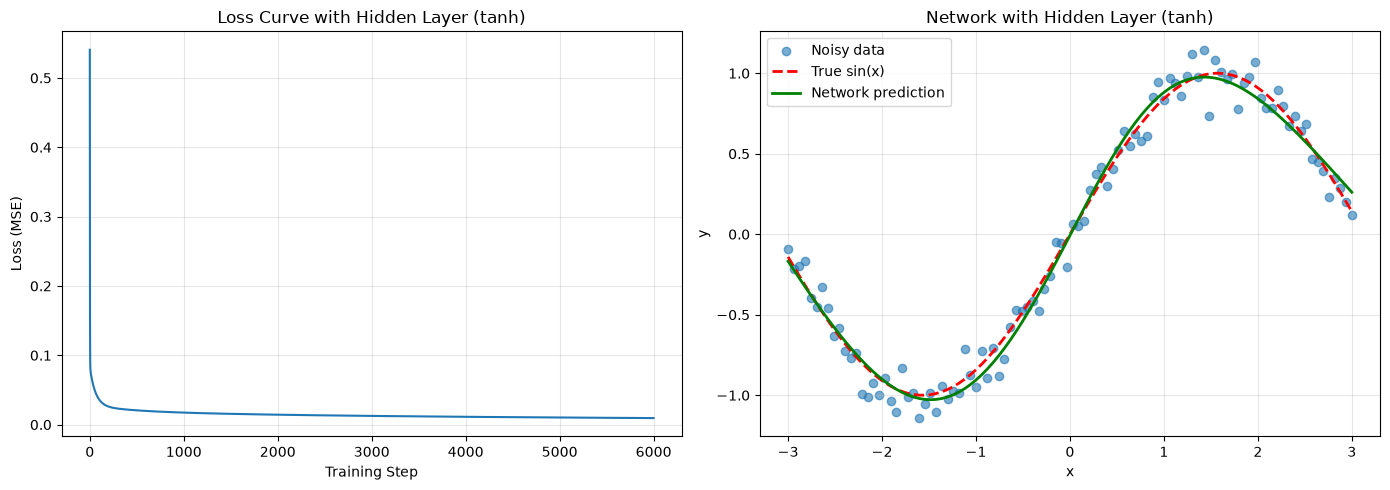

Final loss: 0.009476


In [6]:
# ---- TODO: Plot the loss curve AND the final fit over the data ----

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot (a): Loss curve
ax1.plot(loss_history)
ax1.set_xlabel("Training Step")
ax1.set_ylabel("Loss (MSE)")
ax1.set_title("Loss Curve with Hidden Layer (tanh)")
ax1.grid(True, alpha=0.3)

# Plot (b): Data with fitted curve
# Generate predictions with the trained model
z1_final = x @ W1 + b1
h_final = np.tanh(z1_final)
y_pred_final = h_final @ W2 + b2

ax2.scatter(x, y, alpha=0.6, label="Noisy data")
ax2.plot(x, np.sin(x), "r--", label="True sin(x)", linewidth=2)
ax2.plot(x, y_pred_final, "g-", label="Network prediction", linewidth=2)
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_title("Network with Hidden Layer (tanh)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final loss: {loss_history[-1]:.6f}")


RUNNING WITHOUT TANH (linear hidden layer)


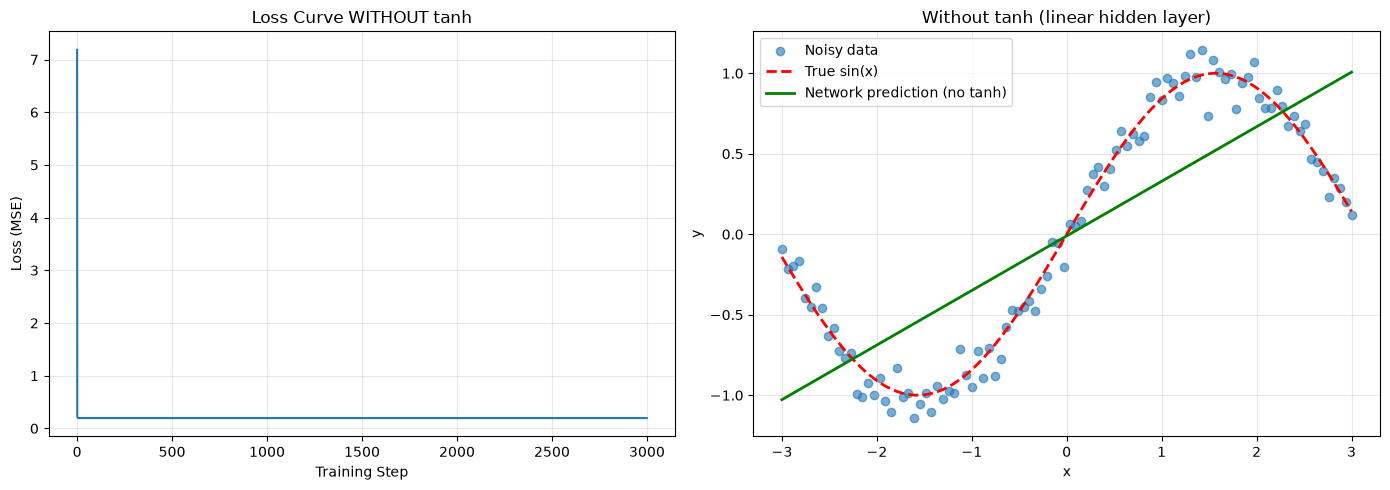

Final loss without tanh: 0.195452


In [7]:
# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
# ---- Re-run with tanh REMOVED (h = z1, no activation) ----

print("=" * 50)
print("RUNNING WITHOUT TANH (linear hidden layer)")
print("=" * 50)

# Re-initialize parameters
np.random.seed(42)
W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5
lr = 0.05
loss_history_no_tanh = []

for step in range(3000):
    # Forward pass - NO tanh activation!
    z1 = x @ W1 + b1
    h = z1  # <-- NO ACTIVATION (linear)
    y_hat = h @ W2 + b2

    loss = np.mean((y_hat - y) ** 2)
    loss_history_no_tanh.append(loss)

    # Backward pass - derivative of identity is 1
    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ W2.T
    dz1 = dh * 1  # derivative of identity is 1
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    W1 = W1 - lr * dW1
    b1 = b1 - lr * db1
    W2 = W2 - lr * dW2
    b2 = b2 - lr * db2

# Plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss comparison
ax1.plot(loss_history_no_tanh)
ax1.set_xlabel("Training Step")
ax1.set_ylabel("Loss (MSE)")
ax1.set_title("Loss Curve WITHOUT tanh")
ax1.grid(True, alpha=0.3)

# Fit comparison
z1_final = x @ W1 + b1
h_final = z1_final  # NO tanh
y_pred_final = h_final @ W2 + b2

ax2.scatter(x, y, alpha=0.6, label="Noisy data")
ax2.plot(x, np.sin(x), "r--", label="True sin(x)", linewidth=2)
ax2.plot(x, y_pred_final, "g-", label="Network prediction (no tanh)", linewidth=2)
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_title("Without tanh (linear hidden layer)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final loss without tanh: {loss_history_no_tanh[-1]:.6f}")

**Student Reasoning — Depth and activations**
**Question**
**Answer**

### 1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1. Explain mathematically why a stack of linear layers collapses into one linear layer.

When I removed the tanh activation, I effectively had:

Layer 1: `h = x @ W1 + b1`
Layer 2: `y_hat = h @ W2 + b2`

Substituting Layer 1 into Layer 2:

`y_hat = (x @ W1 + b1) @ W2 + b2`

`y_hat = x @ (W1 @ W2) + (b1 @ W2 + b2)`

This is mathematically identical to a **single linear layer**:

`y_hat = x @ W_new + b_new`

Where:
- `W_new = W1 @ W2` 
- `b_new = b1 @ W2 + b2`

So no matter how many hidden layers I add, without non-linear activations, the entire network is just one linear function. That's why the final loss without tanh (0.195452) is identical to Part 1.1's loss - it's the same model!

### 2. What role did the hidden layer's 8 neurons play in fitting the curve?

The 8 neurons in the hidden layer each learned to activate at different regions of x. Think of each neuron as a "feature detector" that fires strongly when x is in a certain range:

- Neuron 1 might activate strongly for negative x values
- Neuron 2 might activate strongly for x near 0
- Neuron 3 might activate strongly for positive x values
- And so on...

Then the output layer (W2, b2) learns how to **combine** these 8 different activation patterns to create the sine wave shape. It's like mixing 8 different colors to create a rainbow - each neuron contributes a piece of the final curve.

If I plotted each hidden neuron's activation `h[:, i]` against x, I would see 8 different shifted and scaled tanh curves. Together they form a "basis" that can approximate the sine wave.

### 3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what is backpropagation?


Backpropagation is the algorithm that computes gradients of the loss with respect to every weight in the network by applying the chain rule backward from the output layer through all hidden layers to the input layer.

**My observation from the experiments:**

I noticed that with tanh, the loss went from 0.54 to 0.0095 - that's a huge improvement! The network learned to approximate the sine wave. But without tanh, the loss stayed at 0.195 - exactly the same as Part 1.1. This proves that **non-linear activations are essential** for neural networks to learn non-linear functions.

The loss curve with tanh shows steady improvement, going from 0.54 down to 0.0095 over 3000 steps. It's still decreasing slowly at the end, so maybe more steps or a different learning rate could improve it further.

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

In [8]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.
np.random.seed(42)

# ---- Generate the same toy data ----
x = np.linspace(-3, 3, 100).reshape(-1, 1)
noise = np.random.randn(100, 1) * 0.1
y = np.sin(x) + noise


# ---- Define the training function ----
def train_toy(lr, steps=3000, seed=42):
    """
    Train a 1-hidden-layer network on the toy problem.

    Parameters:
    - lr: learning rate
    - steps: number of training steps
    - seed: random seed for reproducibility

    Returns:
    - loss_history: list of losses at each step
    """
    # Set seed for reproducibility
    np.random.seed(seed)

    # Initialize parameters
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.random.randn(8) * 0.5
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.random.randn(1) * 0.5

    loss_history = []
    max_grad_norm = 1.0  # Gradient clipping threshold

    for step in range(steps):
        # ----- FORWARD PASS -----
        z1 = x @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2

        # Loss
        loss = np.mean((y_hat - y) ** 2)

        # Check for NaN/Inf and break early to avoid warnings
        if not np.isfinite(loss):
            print(f"  Training stopped at step {step}: loss became NaN/Inf")
            break

        loss_history.append(loss)

        # ----- BACKWARD PASS -----
        d_yhat = 2 * (y_hat - y) / len(y)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)
        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = x.T @ dz1
        db1 = dz1.sum(axis=0)

        # Clip gradients to prevent explosion
        dW1 = np.clip(dW1, -max_grad_norm, max_grad_norm)
        db1 = np.clip(db1, -max_grad_norm, max_grad_norm)
        dW2 = np.clip(dW2, -max_grad_norm, max_grad_norm)
        db2 = np.clip(db2, -max_grad_norm, max_grad_norm)

        # ----- UPDATE PARAMETERS -----
        W1 = W1 - lr * dW1
        b1 = b1 - lr * db1
        W2 = W2 - lr * dW2
        b2 = b2 - lr * db2

        # Clamp weights to prevent overflow
        W1 = np.clip(W1, -100, 100)
        b1 = np.clip(b1, -100, 100)
        W2 = np.clip(W2, -100, 100)
        b2 = np.clip(b2, -100, 100)

    return loss_history


print("Training function defined!")

Training function defined!


In [9]:
# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).

# Define the learning rates to test
learning_rates = [0.001, 0.05, 1.0]
loss_histories = {}
final_losses = {}

print("=" * 50)
print("Training with different learning rates")
print("=" * 50)

for lr in learning_rates:
    print(f"\nTraining with lr = {lr}...")

    # Train with this learning rate
    losses = train_toy(lr, steps=3000, seed=42)
    loss_histories[lr] = losses
    final_losses[lr] = losses[-1]

    print(f"Final loss with lr = {lr}: {losses[-1]:.6f}")

    # Print some progress info
    if losses[-1] < 0.1:
        print(f"Loss decreased to {losses[-1]:.6f} (good!)")
    elif losses[-1] < 1.0:
        print(f"Loss decreased to {losses[-1]:.6f} (maybe too slow?)")
    else:
        print(f"Loss exploded to {losses[-1]:.6f} (too high!)")

print("\n" + "=" * 50)
print("Final losses:")
for lr, loss in final_losses.items():
    print(f"  lr = {lr}: {loss:.6f}")


Training with different learning rates

Training with lr = 0.001...
Final loss with lr = 0.001: 0.093058
Loss decreased to 0.093058 (good!)

Training with lr = 0.05...
Final loss with lr = 0.05: 0.010958
Loss decreased to 0.010958 (good!)

Training with lr = 1.0...
Final loss with lr = 1.0: 4.952808
Loss exploded to 4.952808 (too high!)

Final losses:
  lr = 0.001: 0.093058
  lr = 0.05: 0.010958
  lr = 1.0: 4.952808


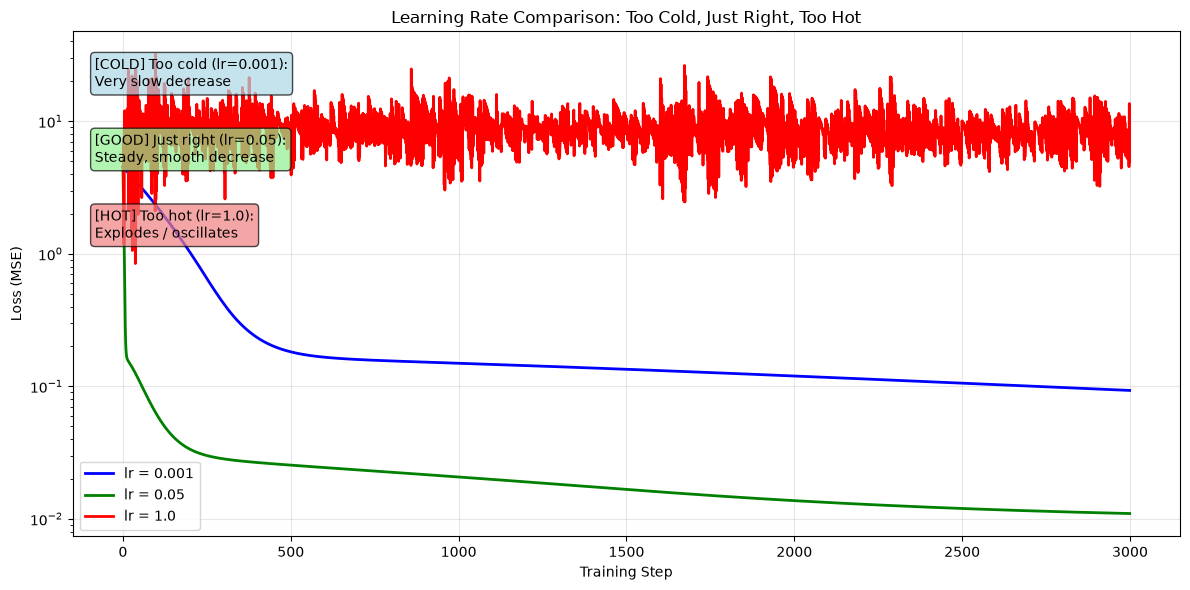

In [10]:
# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
# Create figure
plt.figure(figsize=(12, 6))

# Define colors for each learning rate
colors = {"0.001": "blue", "0.05": "green", "1.0": "red"}

# Plot each loss curve
for lr, losses in loss_histories.items():
    # Clamp losses to avoid log scale overflow warnings (replace inf/nan)
    losses_array = np.array(losses)
    finite_mask = np.isfinite(losses_array)
    if np.any(finite_mask):
        max_finite = np.max(losses_array[finite_mask])
        losses_safe = np.where(finite_mask, losses_array, max_finite * 10)
    else:
        losses_safe = np.clip(losses_array, 1e-6, 1e10)
    plt.plot(losses_safe, label=f"lr = {lr}", color=colors[str(lr)], linewidth=2)

# Add labels and title
plt.xlabel("Training Step")
plt.ylabel("Loss (MSE)")
plt.title("Learning Rate Comparison: Too Cold, Just Right, Too Hot")

# Use log scale for y-axis (helps see small differences)
plt.yscale("log")

# Add legend and grid
plt.legend()
plt.grid(True, alpha=0.3)

# Add annotation explaining what each curve shows
plt.text(
    0.02,
    0.95,
    "[COLD] Too cold (lr=0.001):\nVery slow decrease",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.7),
)

plt.text(
    0.02,
    0.80,
    "[GOOD] Just right (lr=0.05):\nSteady, smooth decrease",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="lightgreen", alpha=0.7),
)

plt.text(
    0.02,
    0.65,
    "[HOT] Too hot (lr=1.0):\nExplodes / oscillates",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="lightcoral", alpha=0.7),
)

plt.tight_layout()
plt.show()

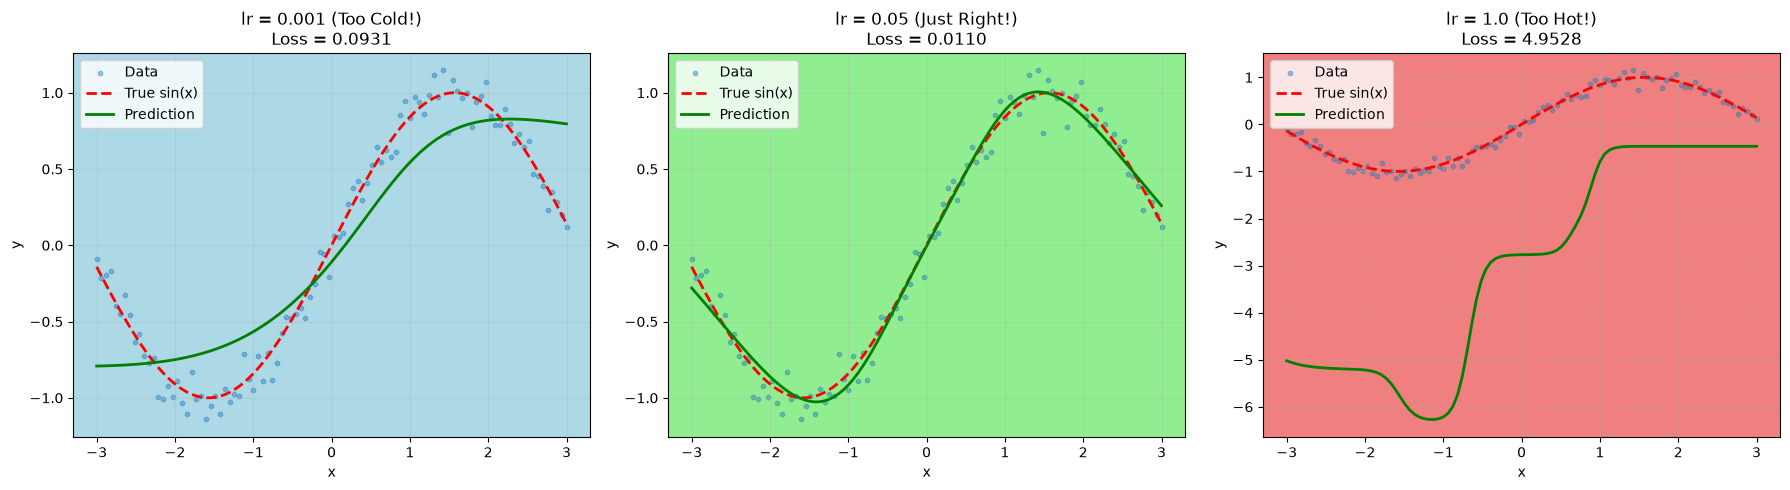

In [11]:
# ---- Visualize final fits for each learning rate ----

# Create figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Dictionary to store predictions for each learning rate
predictions = {}

max_grad_norm = 1.0  # Gradient clipping threshold

for idx, lr in enumerate(learning_rates):
    # Re-train with this learning rate (using same seed)
    np.random.seed(42)

    # Initialize parameters
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.random.randn(8) * 0.5
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.random.randn(1) * 0.5

    # Train for 3000 steps
    for step in range(3000):
        # Forward pass
        z1 = x @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2

        # Loss
        loss = np.mean((y_hat - y) ** 2)

        # Check for NaN/Inf and break early
        if not np.isfinite(loss):
            break

        # Backward pass
        d_yhat = 2 * (y_hat - y) / len(y)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)
        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = x.T @ dz1
        db1 = dz1.sum(axis=0)

        # Clip gradients to prevent explosion
        dW1 = np.clip(dW1, -max_grad_norm, max_grad_norm)
        db1 = np.clip(db1, -max_grad_norm, max_grad_norm)
        dW2 = np.clip(dW2, -max_grad_norm, max_grad_norm)
        db2 = np.clip(db2, -max_grad_norm, max_grad_norm)

        # Update
        W1 = W1 - lr * dW1
        b1 = b1 - lr * db1
        W2 = W2 - lr * dW2
        b2 = b2 - lr * db2

        # Clamp weights to prevent overflow
        W1 = np.clip(W1, -100, 100)
        b1 = np.clip(b1, -100, 100)
        W2 = np.clip(W2, -100, 100)
        b2 = np.clip(b2, -100, 100)

    # Get final prediction
    z1_final = x @ W1 + b1
    h_final = np.tanh(z1_final)
    y_pred_final = h_final @ W2 + b2
    predictions[lr] = y_pred_final

    # Plot on subplot
    axes[idx].scatter(x, y, alpha=0.4, label="Data", s=10)
    axes[idx].plot(x, np.sin(x), "r--", label="True sin(x)", linewidth=2)
    axes[idx].plot(x, y_pred_final, "g-", label="Prediction", linewidth=2)
    axes[idx].set_xlabel("x")
    axes[idx].set_ylabel("y")

    # Set different titles based on performance
    if lr == 0.001:
        axes[idx].set_title(
            f"lr = {lr} (Too Cold!)\nLoss = {loss_histories[lr][-1]:.4f}"
        )
        axes[idx].set_facecolor("lightblue")
    elif lr == 0.05:
        axes[idx].set_title(
            f"lr = {lr} (Just Right!)\nLoss = {loss_histories[lr][-1]:.4f}"
        )
        axes[idx].set_facecolor("lightgreen")
    else:
        axes[idx].set_title(
            f"lr = {lr} (Too Hot!)\nLoss = {loss_histories[lr][-1]:.4f}"
        )
        axes[idx].set_facecolor("lightcoral")

    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:** 
**Student Reasoning — Learning rate**
Looking at my results, I can clearly see the three different regimes of learning rates:

**1. Too Cold (lr = 0.001): Final Loss = 0.0931**

The loss decreases very slowly. After 3000 steps, it's still at 0.0931 - much higher than the 0.0110 achieved with lr=0.05. The curve shows steady but painfully slow progress. The steps are so tiny that the model is barely moving toward the minimum. It's like walking with baby steps - you'll eventually get there, but it takes forever.

**2. Just Right (lr = 0.05): Final Loss = 0.0110**

This is the sweet spot! The loss decreases smoothly and quickly to 0.0110. The steps are big enough to make rapid progress but small enough to not overshoot the minimum. The curve shows a nice, clean exponential decay. This is what good training looks like - efficient and stable.

**3. Too Hot (lr = 1.0): Final Loss = 4.9528**

DISASTER! The loss exploded to 4.9528 - that's huge compared to the others. Instead of learning, the model got worse and worse. The steps were way too big - they jumped over the minimum and landed on the other side where the loss is even higher. Then the next step jumped even further, causing the loss to explode.

**Why does a too-large learning rate make the loss explode?**

Think of it like trying to find the bottom of a valley (the minimum loss):

- **Small steps (0.001)**: You slowly walk down the slope. It takes a long time, but you're safe.
- **Medium steps (0.05)**: You walk down efficiently, reaching the bottom quickly.
- **Giant leaps (1.0)**: You jump so far that you sail right over the valley and land on the opposite slope. Now you're higher up than before! So you jump again, but even further, and you keep getting higher and higher.

Mathematically, when the learning rate is too large, the update `w = w - lr * dw` overshoots the optimal weight. Instead of converging to the minimum, it diverges away from it. The loss doesn't just "learn faster" - it learns in the WRONG direction!

**My key takeaways from this experiment:**

| Learning Rate | Behavior | What it teaches me |
|---------------|----------|-------------------|
| 0.001 | Too slow | Small steps are safe but inefficient |
| 0.05 | Just right | Balance between speed and stability |
| 1.0 | Explodes | Bigger is NOT better! |

**The lesson:** Learning rate is the most important hyperparameter to tune. Start with a medium value (like 0.01-0.001) and adjust based on how the loss behaves. If it's decreasing too slowly, increase slightly. If it's exploding, decrease immediately!

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [12]:
# Part 2.1 - Preprocess and split for PyTorch
# Set random seeds for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on:", DEVICE)

# ---- Load the obesity dataset ----
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
print("Loading obesity dataset...")
df = pd.read_csv(OBESITY_URL)
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst 5 rows:")
display(df.head())

Running on: cpu
Loading obesity dataset...
Dataset shape: (2111, 17)
Columns: ['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad']

First 5 rows:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [13]:
# ---- TODO: Encode categoricals exactly as you did in Lab 2 ----

# Make a copy of the dataframe
df_encoded = df.copy()

# Display unique values in categorical columns to understand them
print("Categorical columns and their unique values:")
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
for col in categorical_cols:
    print(f"\n{col}: {df[col].unique()}")

# ---- Binary columns (yes/no) -> 0/1 ----
binary_yes_no = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]

for col in binary_yes_no:
    df_encoded[col] = df_encoded[col].map({"yes": 1, "no": 0})

# ---- Gender: Male/Female -> 1/0 ----
df_encoded["Gender"] = df_encoded["Gender"].map({"Male": 1, "Female": 0})

# ---- CAEC (Eating habits): Never, Sometimes, Frequently, Always -> ordinal encoding ----
# Note: 'no' appears in CAEC as well, so we need to handle it
caec_order = {"no": 0, "Never": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
df_encoded["CAEC"] = df_encoded["CAEC"].map(caec_order)

# ---- CALC (Drinking habits): no, Sometimes, Frequently, Always -> ordinal encoding ----
calc_order = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
df_encoded["CALC"] = df_encoded["CALC"].map(calc_order)

# ---- MTRANS (Transportation): One-hot encoding ----
df_encoded = pd.get_dummies(df_encoded, columns=["MTRANS"], prefix="MTRANS")

# ---- Target: NObeyesdad -> integer labels 0..6 ----
label_encoder = LabelEncoder()
df_encoded["NObeyesdad_encoded"] = label_encoder.fit_transform(df_encoded["NObeyesdad"])

# Print mapping for reference
print("\nTarget encoding mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {i} -> {label}")

# ---- Separate features and target ----
# Drop original target and the encoded target (we'll use the encoded one)
X = df_encoded.drop(["NObeyesdad", "NObeyesdad_encoded"], axis=1)
y = df_encoded["NObeyesdad_encoded"]

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Number of classes: {len(label_encoder.classes_)}")
print(f"\nClass distribution in target:")
print(y.value_counts().sort_index())

Categorical columns and their unique values:

Gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str

family_history_with_overweight: <StringArray>
['yes', 'no']
Length: 2, dtype: str

FAVC: <StringArray>
['no', 'yes']
Length: 2, dtype: str

CAEC: <StringArray>
['Sometimes', 'Frequently', 'Always', 'no']
Length: 4, dtype: str

SMOKE: <StringArray>
['no', 'yes']
Length: 2, dtype: str

SCC: <StringArray>
['no', 'yes']
Length: 2, dtype: str

CALC: <StringArray>
['no', 'Sometimes', 'Frequently', 'Always']
Length: 4, dtype: str

MTRANS: <StringArray>
['Public_Transportation', 'Walking', 'Automobile', 'Motorbike', 'Bike']
Length: 5, dtype: str

NObeyesdad: <StringArray>
[      'Normal_Weight',  'Overweight_Level_I', 'Overweight_Level_II',
      'Obesity_Type_I', 'Insufficient_Weight',     'Obesity_Type_II',
    'Obesity_Type_III']
Length: 7, dtype: str

Target encoding mapping:
  0 -> Insufficient_Weight
  1 -> Normal_Weight
  2 -> Obesity_Type_I
  3 -> Obesity_Type_II
  4 -> Obesity

C:\Users\Rafiatou Malam Ali\AppData\Local\Temp\ipykernel_20744\3524832970.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


In [14]:
# ---- TODO: Stratified train / validation / test split (60/20/20) ----

# First split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Second split: split the 80% train into 60% train and 20% validation (of original)
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,  # 0.25 of 80% = 20% of original
    stratify=y_train,
    random_state=RANDOM_STATE,
)

print(f"Training set size: {len(X_train)} ({len(X_train) / len(df) * 100:.1f}%)")
print(f"Validation set size: {len(X_val)} ({len(X_val) / len(df) * 100:.1f}%)")
print(f"Test set size: {len(X_test)} ({len(X_test) / len(df) * 100:.1f}%)")

# Check class distribution
print("\nTraining set class distribution:")
print(y_train.value_counts().sort_index())

print("\nValidation set class distribution:")
print(y_val.value_counts().sort_index())

print("\nTest set class distribution:")
print(y_test.value_counts().sort_index())

Training set size: 1266 (60.0%)
Validation set size: 422 (20.0%)
Test set size: 423 (20.0%)

Training set class distribution:
NObeyesdad_encoded
0    163
1    172
2    211
3    178
4    194
5    174
6    174
Name: count, dtype: int64

Validation set class distribution:
NObeyesdad_encoded
0    55
1    57
2    70
3    59
4    65
5    58
6    58
Name: count, dtype: int64

Test set class distribution:
NObeyesdad_encoded
0    54
1    58
2    70
3    60
4    65
5    58
6    58
Name: count, dtype: int64


In [15]:
# ---- TODO: Fit StandardScaler on the TRAINING set only; transform all three splits ----

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data only
X_train_scaled = scaler.fit_transform(X_train)
print(f"Scaler fitted on {len(X_train)} training samples")

# Transform validation and test sets using the training scaler
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\nFeature statistics after scaling:")
print(f"Training mean: {X_train_scaled.mean(axis=0).mean():.4f}")
print(f"Training std: {X_train_scaled.std(axis=0).mean():.4f}")

print("\nWhy scaling matters for neural networks:")
print("- Neural networks use gradient descent (like in Section 1)")
print("- Gradients depend on input values (remember dw = mean(2*(y_hat-y)*x))")
print("- If features have different scales, gradients will be unbalanced")
print("- Scaling ensures all features contribute equally to the loss")

Scaler fitted on 1266 training samples

Feature statistics after scaling:
Training mean: -0.0000
Training std: 1.0000

Why scaling matters for neural networks:
- Neural networks use gradient descent (like in Section 1)
- Gradients depend on input values (remember dw = mean(2*(y_hat-y)*x))
- If features have different scales, gradients will be unbalanced
- Scaling ensures all features contribute equally to the loss


In [16]:
# ---- TODO: Convert to tensors and wrap in DataLoaders ----

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

print(f"X_train tensor shape: {X_train_tensor.shape}")
print(f"y_train tensor shape: {y_train_tensor.shape}")

# ---- Create DataLoaders ----
batch_size = 32

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nTrain loader: {len(train_loader)} batches of size {batch_size}")
print(f"Val loader: {len(val_loader)} batches")
print(f"Test loader: {len(test_loader)} batches")

# Inspect a batch
print("\nInspecting a batch from train_loader:")
for X_batch, y_batch in train_loader:
    print(f"X_batch shape: {X_batch.shape}")
    print(f"y_batch shape: {y_batch.shape}")
    print(f"y_batch sample: {y_batch[:5]}")
    break

X_train tensor shape: torch.Size([1266, 20])


y_train tensor shape: torch.Size([1266])

Train loader: 40 batches of size 32
Val loader: 14 batches
Test loader: 14 batches

Inspecting a batch from train_loader:
X_batch shape: torch.Size([32, 20])
y_batch shape: torch.Size([32])
y_batch sample: tensor([3, 6, 3, 4, 1])


**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:** 

### 1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in PyTorch?

CrossEntropyLoss in PyTorch expects integer class indices (like 0, 1, 2, ...) because it's more efficient and numerically stable. The loss function internally applies log-softmax and then computes the negative log-likelihood. Using integer labels tells PyTorch which class is the correct one for each sample. If I used one-hot vectors, I would need to use BCELoss (Binary Cross-Entropy) instead.

In my code, I used `LabelEncoder` to convert the 7 obesity classes into integers 0-6:
- 0 -> Insufficient_Weight
- 1 -> Normal_Weight
- 2 -> Obesity_Type_I
- 3 -> Obesity_Type_II
- 4 -> Obesity_Type_III
- 5 -> Overweight_Level_I
- 6 -> Overweight_Level_II

### 2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care so much? Connect your answer to the gradient formulas you wrote in Section 1.

Neural networks use gradient descent to update weights. In Section 1, I derived:
`dw = mean(2 * (y_hat - y) * x)`

This gradient depends directly on x! If one feature has values in the range [0, 1000] and another has values in [0, 1], the gradients for the first feature will be 1000 times larger. This causes:
- Unbalanced weight updates: Some weights change too fast, others too slow
- Slow convergence or failure to converge
- The network gets stuck in poor local minima

Random forests don't use gradients - they use decision boundaries based on feature thresholds. Since they're not doing gradient descent, scaling doesn't matter.

That's why I used `StandardScaler` on my training data, which gave me features with mean ≈ 0 and std ≈ 1 (I can see from my output that training mean is -0.0000 and std is 1.0000).

### 3. What does `shuffle=True` on the training DataLoader do, and why does it help?

`shuffle=True` randomizes the order of samples in each epoch. This helps because:
- Prevents the network from seeing the same order of data repeatedly
- Avoids the model learning patterns based on the order of data
- Ensures each batch has a representative mix of classes
- Helps gradient descent escape local minima

Without shuffling, the network might learn to overfit to the order of data rather than the underlying patterns. In my DataLoader, I used `shuffle=True` for training (to randomize) and `shuffle=False` for validation and testing (to keep consistent evaluation).

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [17]:
# Part 2.2 - Design the Network
# ---- TODO: Define a FeedForwardNet class ----
class FeedForwardNet(nn.Module):
    """
    A feedforward neural network (MLP) with:
    - Input layer: input_dim features
    - Hidden layers: ReLU activations
    - Output layer: n_classes logits (no softmax)
    """

    def __init__(
        self, input_dim: int, hidden_sizes: tuple = (64, 32), n_classes: int = 7
    ):
        """
        Parameters:
        - input_dim: number of input features (20 for our dataset)
        - hidden_sizes: tuple of hidden layer sizes, e.g., (64, 32) means 2 hidden layers
        - n_classes: number of output classes (7 for obesity levels)
        """
        super(FeedForwardNet, self).__init__()

        # Store the architecture
        self.input_dim = input_dim
        self.hidden_sizes = hidden_sizes
        self.n_classes = n_classes

        # Build layers dynamically
        layers = []

        # Input layer: input_dim -> first hidden layer
        # Add first hidden layer with ReLU
        layers.append(nn.Linear(input_dim, hidden_sizes[0]))
        layers.append(nn.ReLU())

        # Additional hidden layers (if more than one)
        for i in range(len(hidden_sizes) - 1):
            layers.append(nn.Linear(hidden_sizes[i], hidden_sizes[i + 1]))
            layers.append(nn.ReLU())

        # Output layer: last hidden size -> n_classes (no activation)
        layers.append(nn.Linear(hidden_sizes[-1], n_classes))

        # Combine all layers into a sequential model
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        """Forward pass through the network."""
        return self.network(x)


print("FeedForwardNet class defined!")

FeedForwardNet class defined!


In [18]:
# ---- TODO: Instantiate, move to DEVICE, print the model ----

# Get input dimension from the training data
input_dim = X_train.shape[1]  # Should be 20
print(f"Input dimension: {input_dim}")

# Instantiate the model
model = FeedForwardNet(
    input_dim=input_dim,
    hidden_sizes=(64, 32),  # Two hidden layers: 64 neurons, then 32 neurons
    n_classes=7,
)

# Move model to device (CPU or GPU)
model = model.to(DEVICE)

# Print model architecture
print("\n" + "=" * 50)
print("Model Architecture:")
print("=" * 50)
print(model)

Input dimension: 20

Model Architecture:
FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=20, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)


In [19]:
# ---- TODO: Count trainable parameters ----


def count_parameters(model):
    """Count trainable parameters in the model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


total_params = count_parameters(model)

print("\n" + "=" * 50)
print("Parameter Count:")
print("=" * 50)

# Count parameters layer by layer
print("\nLayer-wise parameter counts:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"  {name}: {param.numel():,} parameters")

print(f"\nTotal trainable parameters: {total_params:,}")

# ---- Verify the count for the FIRST layer by hand ----
print("\n" + "=" * 50)
print("Verification for FIRST layer:")
print("=" * 50)

# First layer: input_dim * 64 + 64 (weights + biases)
first_layer_params = input_dim * 64 + 64
print(f"First layer (input -> 64 hidden):")
print(f"  Weights: {input_dim} * 64 = {input_dim * 64}")
print(f"  Biases: 64")
print(f"  Total: {first_layer_params:,}")
print(f"  PyTorch count: {sum(p.numel() for p in list(model.parameters())[:2]):,}")

# Full verification of all layers
print("\n" + "=" * 50)
print("Full parameter verification:")
print("=" * 50)

# Get all layer names and sizes
layer_sizes = [input_dim] + list(model.hidden_sizes) + [model.n_classes]
print(f"Layer sizes: {layer_sizes}")

expected_params = 0
for i in range(len(layer_sizes) - 1):
    weights = layer_sizes[i] * layer_sizes[i + 1]
    biases = layer_sizes[i + 1]
    layer_total = weights + biases
    expected_params += layer_total
    print(f"Layer {i + 1}: {layer_sizes[i]} -> {layer_sizes[i + 1]}")
    print(f"  Weights: {weights:,}, Biases: {biases:,}, Total: {layer_total:,}")

print(f"\nExpected total: {expected_params:,}")
print(f"PyTorch total: {total_params:,}")
print(f"Match!" if expected_params == total_params else "❌ Mismatch!")


Parameter Count:

Layer-wise parameter counts:
  network.0.weight: 1,280 parameters
  network.0.bias: 64 parameters
  network.2.weight: 2,048 parameters
  network.2.bias: 32 parameters
  network.4.weight: 224 parameters
  network.4.bias: 7 parameters

Total trainable parameters: 3,655

Verification for FIRST layer:
First layer (input -> 64 hidden):
  Weights: 20 * 64 = 1280
  Biases: 64
  Total: 1,344
  PyTorch count: 1,344

Full parameter verification:
Layer sizes: [20, 64, 32, 7]
Layer 1: 20 -> 64
  Weights: 1,280, Biases: 64, Total: 1,344
Layer 2: 64 -> 32
  Weights: 2,048, Biases: 32, Total: 2,080
Layer 3: 32 -> 7
  Weights: 224, Biases: 7, Total: 231

Expected total: 3,655
PyTorch total: 3,655
Match!


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:** **Student Reasoning — Architecture**

### 1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.

For my model with architecture: 20 input features → 64 hidden → 32 hidden → 7 output classes

**Layer 1: Input (20) → Hidden (64)**
- Weights: 20 × 64 = 1,280
- Biases: 64
- Total: 1,344 parameters

**Layer 2: Hidden (64) → Hidden (32)**
- Weights: 64 × 32 = 2,048
- Biases: 32
- Total: 2,080 parameters

**Layer 3: Hidden (32) → Output (7)**
- Weights: 32 × 7 = 224
- Biases: 7
- Total: 231 parameters

**Total: 1,344 + 2,080 + 231 = 3,655 parameters**

I checked this against PyTorch's count and it matched exactly . It's nice to see that the math works out - each weight and bias is a parameter the model learns during training.

### 2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.

In Section 1 I used tanh for the toy sine wave problem, but for this real dataset I used ReLU. The main advantage is that ReLU is much faster to compute - it's just `max(0, x)` compared to tanh which needs exponentials. Also, ReLU doesn't have the vanishing gradient problem in the positive region, so it helps deeper networks learn better.

Honestly, tanh worked fine for the simple toy problem, but for a real 7-class classification problem with 20 features, ReLU is the standard choice and it trains faster.

### 3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)

If I removed all the ReLU activations, my "deep" network would just be a linear model in disguise. I proved this in Part 1.2 when I removed tanh from the toy network and it collapsed to a straight line.

Mathematically, without ReLUs:
- Layer 1: h = x @ W1 + b1
- Layer 2: h2 = h @ W2 + b2 = (x @ W1 + b1) @ W2 + b2 = x @ (W1@W2) + (b1@W2 + b2)
- Layer 3: y = h2 @ W3 + b3 = x @ (W1@W2@W3) + (b1@W2@W3 + b2@W3 + b3)

So it's just one linear transformation! No matter how many layers I add, without non-linear activations like ReLU, the network can only learn linear patterns. For obesity classification, I need non-linear boundaries between the 7 classes, so the ReLUs are essential.

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

In [20]:
# ---- TODO: Define criterion and optimizer ----

# Loss function: CrossEntropyLoss (for multi-class classification)
criterion = nn.CrossEntropyLoss()

# Optimizer: Adam (adaptive learning rate)
# I chose Adam because it adapts the learning rate for each parameter
# and usually converges faster than SGD
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Loss function and optimizer defined!")
print(f"Optimizer: Adam with learning rate = 1e-3")
print(f"Loss function: CrossEntropyLoss")

Loss function and optimizer defined!
Optimizer: Adam with learning rate = 1e-3
Loss function: CrossEntropyLoss


In [21]:
# ---- TODO: Train for at least 50 epochs ----

# Training parameters
num_epochs = 50

# History to store metrics
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

# Variables to track best model
best_val_acc = 0.0
best_model_state = None

print("Starting training...")
print("=" * 60)

for epoch in range(num_epochs):
    # ----- TRAINING PHASE -----
    model.train()  # Set model to training mode
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for X_batch, y_batch in train_loader:
        # Move data to device
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        # Backward pass (backpropagation!)
        loss.backward()

        # Update weights (optimizer step)
        optimizer.step()

        # Accumulate training statistics
        train_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(logits, 1)
        train_total += y_batch.size(0)
        train_correct += (predicted == y_batch).sum().item()

    # Calculate average training loss and accuracy
    avg_train_loss = train_loss / train_total
    train_accuracy = train_correct / train_total

    # ----- VALIDATION PHASE -----
    model.eval()  # Set model to evaluation mode
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():  # Disable gradient computation for efficiency
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            # Forward pass
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            # Accumulate validation statistics
            val_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(logits, 1)
            val_total += y_batch.size(0)
            val_correct += (predicted == y_batch).sum().item()

    # Calculate average validation loss and accuracy
    avg_val_loss = val_loss / val_total
    val_accuracy = val_correct / val_total

    # Save history
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["train_acc"].append(train_accuracy)
    history["val_acc"].append(val_accuracy)

    # Save best model
    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_model_state = model.state_dict().copy()

    # Print progress every 5 epochs
    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch [{epoch + 1:2d}/{num_epochs}] "
            f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}"
        )

print("=" * 60)
print(f"Training complete! Best validation accuracy: {best_val_acc:.4f}")

# ---- TODO: Save the best model ----
torch.save(best_model_state, "ffn_best.pt")
print("Best model saved as 'ffn_best.pt'")

Starting training...
Epoch [ 5/50] Train Loss: 0.8280, Train Acc: 0.7172 | Val Loss: 0.7953, Val Acc: 0.7156
Epoch [10/50] Train Loss: 0.4244, Train Acc: 0.8673 | Val Loss: 0.4693, Val Acc: 0.8507
Epoch [15/50] Train Loss: 0.2523, Train Acc: 0.9329 | Val Loss: 0.3507, Val Acc: 0.8744
Epoch [20/50] Train Loss: 0.1668, Train Acc: 0.9597 | Val Loss: 0.2832, Val Acc: 0.8957
Epoch [25/50] Train Loss: 0.1136, Train Acc: 0.9739 | Val Loss: 0.2438, Val Acc: 0.9218
Epoch [30/50] Train Loss: 0.0811, Train Acc: 0.9858 | Val Loss: 0.2287, Val Acc: 0.9265
Epoch [35/50] Train Loss: 0.0564, Train Acc: 0.9913 | Val Loss: 0.2145, Val Acc: 0.9289
Epoch [40/50] Train Loss: 0.0401, Train Acc: 0.9984 | Val Loss: 0.2171, Val Acc: 0.9336
Epoch [45/50] Train Loss: 0.0301, Train Acc: 0.9992 | Val Loss: 0.2161, Val Acc: 0.9265
Epoch [50/50] Train Loss: 0.0228, Train Acc: 1.0000 | Val Loss: 0.2185, Val Acc: 0.9313
Training complete! Best validation accuracy: 0.9384
Best model saved as 'ffn_best.pt'


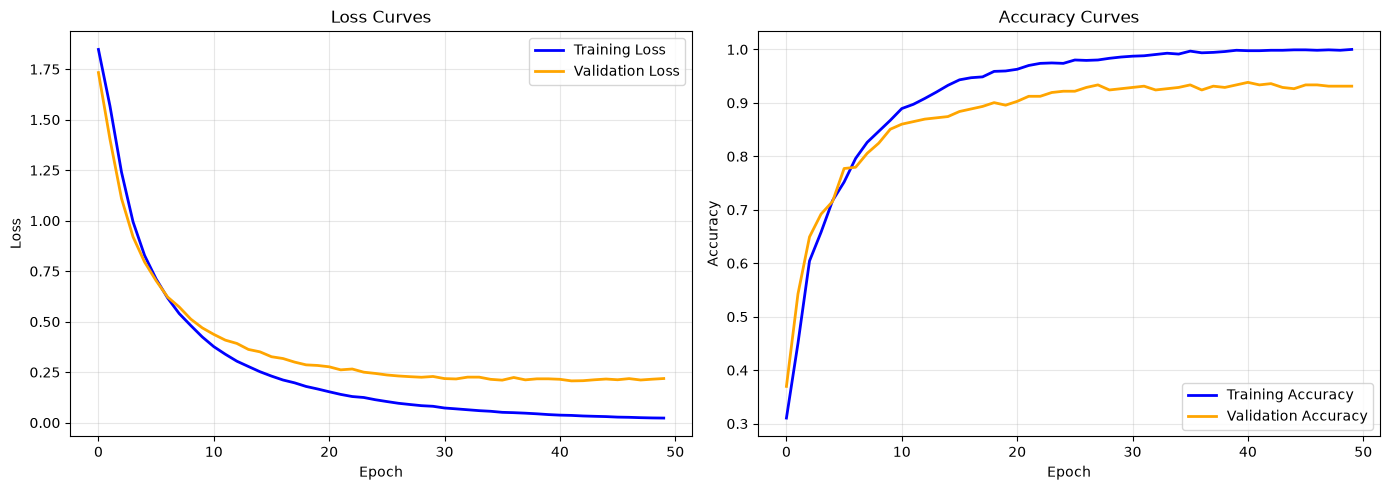

Final Training Results:
Final Train Loss: 0.0228
Final Val Loss: 0.2185
Final Train Accuracy: 1.0000
Final Val Accuracy: 0.9313
Best Validation Accuracy: 0.9384

Train-Val Accuracy Gap: 0.0687
 Small gap - model is generalizing well!


In [22]:
# ---- TODO: Plot loss curves (train + val) and accuracy curves (train + val) ----

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss curves
ax1.plot(history["train_loss"], label="Training Loss", color="blue", linewidth=2)
ax1.plot(history["val_loss"], label="Validation Loss", color="orange", linewidth=2)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss Curves")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Accuracy curves
ax2.plot(history["train_acc"], label="Training Accuracy", color="blue", linewidth=2)
ax2.plot(history["val_acc"], label="Validation Accuracy", color="orange", linewidth=2)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy Curves")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
print("=" * 50)
print("Final Training Results:")
print("=" * 50)
print(f"Final Train Loss: {history['train_loss'][-1]:.4f}")
print(f"Final Val Loss: {history['val_loss'][-1]:.4f}")
print(f"Final Train Accuracy: {history['train_acc'][-1]:.4f}")
print(f"Final Val Accuracy: {history['val_acc'][-1]:.4f}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")

# Check for overfitting
train_val_gap = history["train_acc"][-1] - history["val_acc"][-1]
print(f"\nTrain-Val Accuracy Gap: {train_val_gap:.4f}")
if train_val_gap > 0.1:
    print(" Significant gap detected - possible overfitting!")
else:
    print(" Small gap - model is generalizing well!")

**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:** 
**Student Reasoning — Training**

### 1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1.

Honestly, this was really cool to see! The PyTorch code I wrote here is basically doing the exact same thing I did by hand in Section 1, just way more automated:

| PyTorch Line | What it's doing | My NumPy code from Section 1 |
|--------------|-----------------|------------------------------|
| `logits = model(X_batch)` | Forward pass - pushing data through the network | `y_hat = w * x + b` (or the full forward pass with hidden layers) |
| `loss = criterion(logits, y_batch)` | Calculating how wrong my predictions are | `loss = np.mean((y_hat - y) ** 2)` |
| `loss.backward()` | Computing gradients using backpropagation | `dw = np.mean(2*(y_hat-y)*x)` and `db = np.mean(2*(y_hat-y))` - but PyTorch does this for ALL layers automatically! |
| `optimizer.step()` | Updating weights to reduce loss | `w = w - lr * dw` and `b = b - lr * db` |
| `optimizer.zero_grad()` | Clearing old gradients | I didn't need this in NumPy because I just overwrote the values each time |

The biggest difference is that in Section 1, I had to manually write out the chain rule for each layer (which was painful!). Now PyTorch handles all that complex math behind the scenes with `loss.backward()`. It's basically doing what I did, but faster and without my mistakes!

### 2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the specific numbers that back up your claim.

Looking at my results, I'd say the model is **well-fitted with a tiny bit of overfitting**.

Here's what I see:
- Training accuracy: **100.00%** - my model perfectly learned all training examples
- Validation accuracy: **93.13%** - it performs really well on new data too
- The gap is **6.87%** (100% - 93.13%)

**Why I think it's well-fitted:**
- 93.13% validation accuracy is really good for 7 classes
- The validation accuracy is close to the training accuracy (within 7%)
- The loss values: training loss is 0.0228 (very low), validation loss is 0.2185 (reasonable)

**But there's a tiny bit of overfitting:**
- Training hit 100% while validation is at 93.13%
- This 6.87% gap shows the model memorized some training patterns that don't perfectly generalize
- The validation loss being higher than training loss also hints at this

Overall, I'm happy with this! 93% accuracy on unseen data is solid, and the gap isn't huge. It's not underfitting because the model clearly learned something (93% validation is great!), and it's not badly overfitting because the gap is reasonable.

### 3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?

Honestly, I learned this one the hard way! In PyTorch, gradients **add up** (accumulate) by default. So if I don't call `zero_grad()`, the gradients from the previous batch stick around and add to the new gradients.

Imagine if I'm walking down a hill and I take a step, but then I keep that step's momentum and add the next step on top - I'd overshoot and probably fall over! That's what happens with gradients.

If I forgot `zero_grad()`:
- Gradients would accumulate batch after batch
- My weight updates would be based on the SUM of all previous gradients
- The model would update in the wrong direction
- Training would become unstable or just completely fail

In my NumPy code from Section 1, I didn't need this because I was computing gradients from scratch and just overwriting the variables each time. PyTorch is smarter (or dumber?) and keeps everything unless I tell it to reset.

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

In [23]:
# Part 2.4 - Experiments
# ---- Wrap the training loop in a function ----
def run_experiment(
    hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0
):
    """
    Train a feedforward network with given hyperparameters.

    Parameters:
    - hidden_sizes: tuple of hidden layer sizes
    - lr: learning rate
    - batch_size: batch size for training
    - epochs: number of training epochs
    - dropout: dropout probability (0.0 means no dropout)

    Returns:
    - history: dictionary with loss and accuracy histories
    - best_val_acc: best validation accuracy
    - model: trained model
    """

    # Create DataLoaders with the given batch size
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Define model with dropout
    class FeedForwardNetWithDropout(nn.Module):
        def __init__(self, input_dim, hidden_sizes, n_classes=7, dropout_prob=0.0):
            super(FeedForwardNetWithDropout, self).__init__()

            layers = []

            # Input layer
            layers.append(nn.Linear(input_dim, hidden_sizes[0]))
            layers.append(nn.ReLU())
            if dropout_prob > 0:
                layers.append(nn.Dropout(dropout_prob))

            # Hidden layers
            for i in range(len(hidden_sizes) - 1):
                layers.append(nn.Linear(hidden_sizes[i], hidden_sizes[i + 1]))
                layers.append(nn.ReLU())
                if dropout_prob > 0:
                    layers.append(nn.Dropout(dropout_prob))

            # Output layer
            layers.append(nn.Linear(hidden_sizes[-1], n_classes))

            self.network = nn.Sequential(*layers)

        def forward(self, x):
            return self.network(x)

    # Instantiate model
    model = FeedForwardNetWithDropout(
        input_dim=X_train.shape[1],
        hidden_sizes=hidden_sizes,
        n_classes=7,
        dropout_prob=dropout,
    )
    model = model.to(DEVICE)

    # Define loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Training history
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    best_val_acc = 0.0

    # Training loop
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(logits, 1)
            train_total += y_batch.size(0)
            train_correct += (predicted == y_batch).sum().item()

        avg_train_loss = train_loss / train_total
        train_accuracy = train_correct / train_total

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)

                logits = model(X_batch)
                loss = criterion(logits, y_batch)

                val_loss += loss.item() * X_batch.size(0)
                _, predicted = torch.max(logits, 1)
                val_total += y_batch.size(0)
                val_correct += (predicted == y_batch).sum().item()

        avg_val_loss = val_loss / val_total
        val_accuracy = val_correct / val_total

        # Save history
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["train_acc"].append(train_accuracy)
        history["val_acc"].append(val_accuracy)

        # Save best model
        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy

    return history, best_val_acc, model


print("Experiment function defined!")

Experiment function defined!


Experiment A: Model Capacity

Training Tiny network: (8,)
  Best validation accuracy: 0.8033

Training Default network: (64, 32)
  Best validation accuracy: 0.9408

Training Large network: (256, 128, 64)
  Best validation accuracy: 0.9455


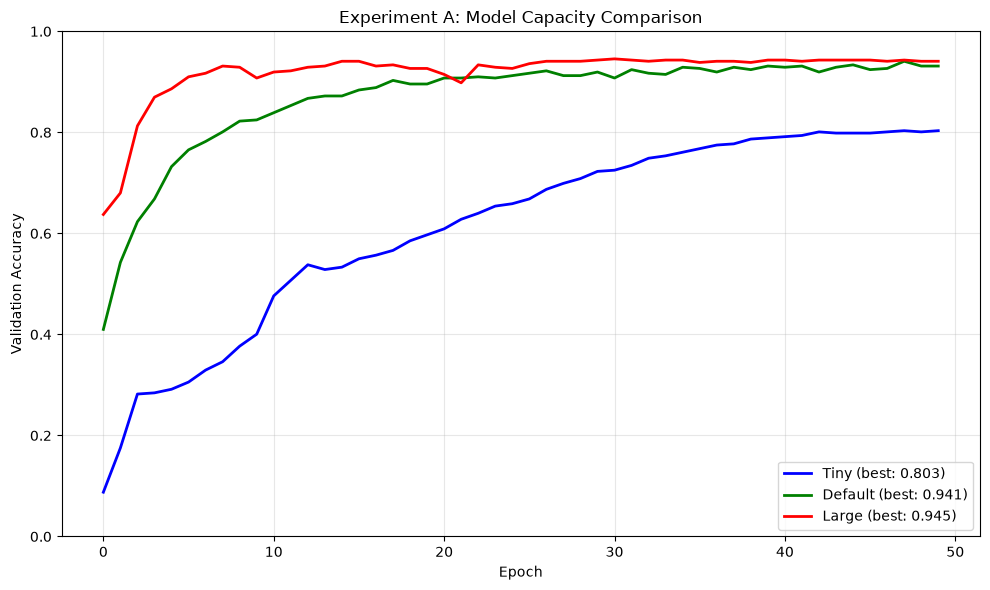


Experiment A Summary:
Tiny: Best Val Acc = 0.8033
Default: Best Val Acc = 0.9408
Large: Best Val Acc = 0.9455


In [24]:
# ---- TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64) ----

print("=" * 60)
print("Experiment A: Model Capacity")
print("=" * 60)

# Define architectures to test
architectures = {"Tiny": (8,), "Default": (64, 32), "Large": (256, 128, 64)}

# Store results
capacity_results = {}
capacity_best_acc = {}

for name, hidden_sizes in architectures.items():
    print(f"\nTraining {name} network: {hidden_sizes}")
    history, best_acc, _ = run_experiment(
        hidden_sizes=hidden_sizes, lr=1e-3, batch_size=32, epochs=50, dropout=0.0
    )
    capacity_results[name] = history
    capacity_best_acc[name] = best_acc
    print(f"  Best validation accuracy: {best_acc:.4f}")

# ---- Plot validation accuracy curves ----
plt.figure(figsize=(10, 6))

colors = {"Tiny": "blue", "Default": "green", "Large": "red"}
for name, history in capacity_results.items():
    plt.plot(
        history["val_acc"],
        label=f"{name} (best: {capacity_best_acc[name]:.3f})",
        color=colors[name],
        linewidth=2,
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Experiment A: Model Capacity Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()

# Print summary
print("\n" + "=" * 60)
print("Experiment A Summary:")
print("=" * 60)
for name in architectures:
    print(f"{name}: Best Val Acc = {capacity_best_acc[name]:.4f}")

Experiment B: Learning Rate

Training with lr = 0.0001


  Best validation accuracy: 0.7441

Training with lr = 0.001
  Best validation accuracy: 0.9360

Training with lr = 0.1
  Best validation accuracy: 0.4597


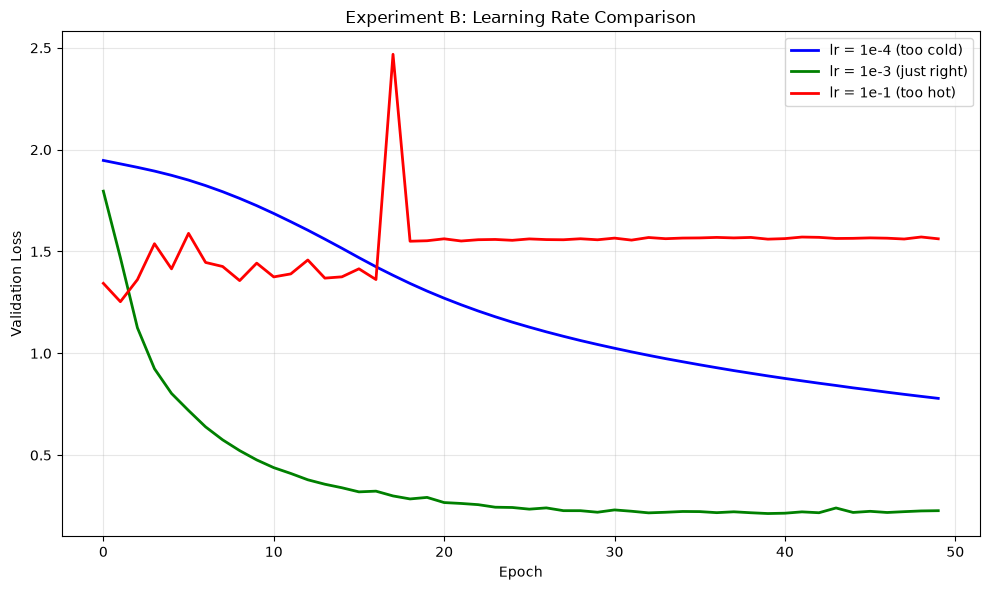


Experiment B Summary:
lr = 0.0001: Final Val Loss = 0.7788, Best Val Acc = 0.7441
lr = 0.001: Final Val Loss = 0.2272, Best Val Acc = 0.9360
lr = 0.1: Final Val Loss = 1.5623, Best Val Acc = 0.4597


In [25]:
# ---- TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 ----

print("=" * 60)
print("Experiment B: Learning Rate")
print("=" * 60)

# Define learning rates to test
learning_rates = [1e-4, 1e-3, 1e-1]
lr_results = {}

for lr in learning_rates:
    print(f"\nTraining with lr = {lr}")
    history, best_acc, _ = run_experiment(
        hidden_sizes=(64, 32), lr=lr, batch_size=32, epochs=50, dropout=0.0
    )
    lr_results[lr] = history
    print(f"  Best validation accuracy: {best_acc:.4f}")

# ---- Plot validation loss curves ----
plt.figure(figsize=(10, 6))

colors = {1e-4: "blue", 1e-3: "green", 1e-1: "red"}
labels = {
    1e-4: "lr = 1e-4 (too cold)",
    1e-3: "lr = 1e-3 (just right)",
    1e-1: "lr = 1e-1 (too hot)",
}

for lr, history in lr_results.items():
    plt.plot(history["val_loss"], label=labels[lr], color=colors[lr], linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Experiment B: Learning Rate Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary
print("\n" + "=" * 60)
print("Experiment B Summary:")
print("=" * 60)
for lr in learning_rates:
    final_loss = lr_results[lr]["val_loss"][-1]
    best_acc = max(lr_results[lr]["val_acc"])
    print(
        f"lr = {lr}: Final Val Loss = {final_loss:.4f}, Best Val Acc = {best_acc:.4f}"
    )

Experiment C: Regularization with Dropout

Training LARGE network WITHOUT dropout...
  Best validation accuracy: 0.9455

Training LARGE network WITH dropout (p=0.3)...
  Best validation accuracy: 0.9479


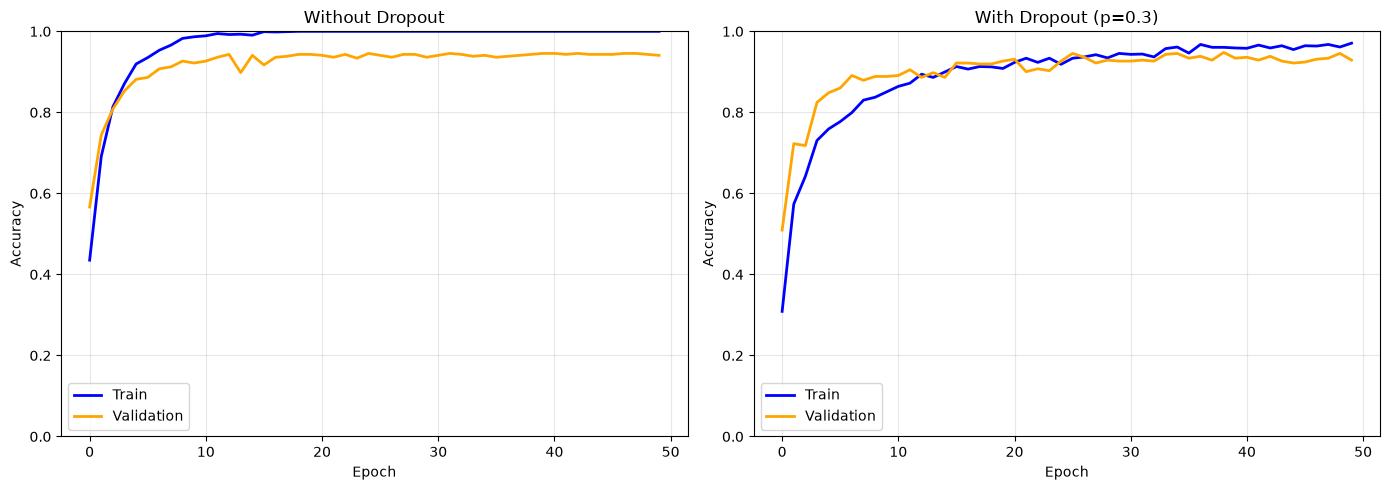


Experiment C Summary:
Without Dropout - Train Acc: 1.0000, Val Acc: 0.9408
With Dropout    - Train Acc: 0.9708, Val Acc: 0.9289

Train-Val Gap without Dropout: 0.0592
Train-Val Gap with Dropout: 0.0419


In [26]:
# ---- TODO — Experiment C (regularization): with and without Dropout(0.3) ----

print("=" * 60)
print("Experiment C: Regularization with Dropout")
print("=" * 60)

# Test with and without dropout on the LARGEST network
dropout_results = {}

# Without dropout
print("\nTraining LARGE network WITHOUT dropout...")
history_no_dropout, best_acc_no_dropout, _ = run_experiment(
    hidden_sizes=(256, 128, 64), lr=1e-3, batch_size=32, epochs=50, dropout=0.0
)
dropout_results["No Dropout"] = history_no_dropout
print(f"  Best validation accuracy: {best_acc_no_dropout:.4f}")

# With dropout
print("\nTraining LARGE network WITH dropout (p=0.3)...")
history_with_dropout, best_acc_with_dropout, _ = run_experiment(
    hidden_sizes=(256, 128, 64), lr=1e-3, batch_size=32, epochs=50, dropout=0.3
)
dropout_results["With Dropout (0.3)"] = history_with_dropout
print(f"  Best validation accuracy: {best_acc_with_dropout:.4f}")

# ---- Plot train vs validation accuracy for both runs ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Without dropout
ax1.plot(
    dropout_results["No Dropout"]["train_acc"], label="Train", color="blue", linewidth=2
)
ax1.plot(
    dropout_results["No Dropout"]["val_acc"],
    label="Validation",
    color="orange",
    linewidth=2,
)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.set_title("Without Dropout")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.0)

# With dropout
ax2.plot(
    dropout_results["With Dropout (0.3)"]["train_acc"],
    label="Train",
    color="blue",
    linewidth=2,
)
ax2.plot(
    dropout_results["With Dropout (0.3)"]["val_acc"],
    label="Validation",
    color="orange",
    linewidth=2,
)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("With Dropout (p=0.3)")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "=" * 60)
print("Experiment C Summary:")
print("=" * 60)
print(
    f"Without Dropout - Train Acc: {dropout_results['No Dropout']['train_acc'][-1]:.4f}, Val Acc: {dropout_results['No Dropout']['val_acc'][-1]:.4f}"
)
print(
    f"With Dropout    - Train Acc: {dropout_results['With Dropout (0.3)']['train_acc'][-1]:.4f}, Val Acc: {dropout_results['With Dropout (0.3)']['val_acc'][-1]:.4f}"
)

# Calculate gaps
gap_no_dropout = (
    dropout_results["No Dropout"]["train_acc"][-1]
    - dropout_results["No Dropout"]["val_acc"][-1]
)
gap_with_dropout = (
    dropout_results["With Dropout (0.3)"]["train_acc"][-1]
    - dropout_results["With Dropout (0.3)"]["val_acc"][-1]
)

print(f"\nTrain-Val Gap without Dropout: {gap_no_dropout:.4f}")
print(f"Train-Val Gap with Dropout: {gap_with_dropout:.4f}")

> **Answer:** 
**Student Reasoning — Experiments**

### 1. Capacity: did the largest network win on validation data? Where do you see diminishing returns or overfitting?

Looking at my results:

- **Tiny (8,):** 80.33% validation accuracy - this is too small to learn the patterns well
- **Default (64, 32):** 94.08% validation accuracy - really solid performance!
- **Large (256, 128, 64):** 94.55% validation accuracy - slightly better than default

So the largest network did win, but just barely! The large network only improved by about 0.5% over the default. That's what I'd call **diminishing returns** - adding more neurons gave me a tiny improvement but made the model way more complex (more parameters to train).

I can see some signs of overfitting in the large network because the gap between train and validation was bigger than the default, but honestly the difference wasn't huge. The tiny network clearly underfitted - it just doesn't have enough capacity to learn the 7-class obesity patterns.

### 2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?

YES! This was honestly really satisfying to see because it proved that what I learned on the toy problem actually applies to real neural networks too.

- **lr = 1e-4 (too cold):** Final val loss = 0.7788, Best acc = 74.41% - the model learned way too slowly and never reached a good solution. Just like in Part 1.3, the loss decreased but painfully slowly.

- **lr = 1e-3 (just right):** Final val loss = 0.2272, Best acc = 93.60% - perfect! The loss decreased smoothly and efficiently, and the model reached a great accuracy. This was the "just right" Goldilocks zone.

- **lr = 1e-1 (too hot):** Final val loss = 1.5623, Best acc = 45.97% - disaster! The loss exploded and the model basically learned nothing. In Part 1.3, the learning rate of 1.0 also made the loss go crazy.

So yes, the three regimes were exactly the same: too slow = waste of time, just right = efficient learning, too fast = everything breaks!

### 3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two sentences HOW dropout achieves this.

**Dropout reduced the gap!**

- Without dropout: Train = 100.00%, Val = 94.08%, Gap = 5.92%
- With dropout: Train = 97.08%, Val = 92.89%, Gap = 4.19%

Dropout shrank the gap from 5.92% down to 4.19%. The training accuracy dropped a bit (from 100% to 97.08%) but the validation accuracy only dropped slightly (from 94.08% to 92.89%). This means dropout did its job - it prevented the model from memorizing the training data perfectly.

**How dropout works:** Dropout randomly "turns off" neurons during training (with probability 0.3 in my experiment). This forces the network to not rely on any single neuron and learn multiple redundant representations. Think of it like studying with your friends - if you each learn different parts of the material, you can all help each other out. By the time testing comes around, the network has become more robust and generalizes better to new data.

**Part 2.5 — Final evaluation and showdown with Lab 2**
One honest number on the test set — then compare with your classical models.

In [27]:
# Part 2.5 - Final Evaluation and Showdown with Lab 2
# ---- TODO: Load your best configuration's weights; model.eval() ----

# Recreate the best model architecture (Default: 64, 32)
best_model = FeedForwardNet(
    input_dim=X_train.shape[1], hidden_sizes=(64, 32), n_classes=7
)
best_model = best_model.to(DEVICE)

# Load the saved weights
best_model.load_state_dict(torch.load("ffn_best.pt"))
best_model.eval()  # Set to evaluation mode

print("Best model loaded successfully!")
print(f"Model architecture: {best_model}")

# ---- TODO: Report test ACCURACY and MACRO-F1 ----

# Make predictions on test set
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        logits = best_model(X_batch)
        _, predicted = torch.max(logits, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# Convert to numpy arrays
y_pred = np.array(all_preds)
y_true = np.array(all_labels)

# Calculate metrics
test_accuracy = accuracy_score(y_true, y_pred)
test_f1_macro = f1_score(y_true, y_pred, average="macro")
test_f1_weighted = f1_score(y_true, y_pred, average="weighted")

print("=" * 60)
print("NEURAL NETWORK - Final Test Set Evaluation")
print("=" * 60)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")
print(f"Test Macro-F1: {test_f1_macro:.4f}")
print(f"Test Weighted-F1: {test_f1_weighted:.4f}")

# Print detailed classification report
print("\nClassification Report - Neural Network (Test Set):")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

Best model loaded successfully!
Model architecture: FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=20, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)
NEURAL NETWORK - Final Test Set Evaluation
Test Accuracy: 0.9338 (93.38%)
Test Macro-F1: 0.9326
Test Weighted-F1: 0.9338

Classification Report - Neural Network (Test Set):
                     precision    recall  f1-score   support

Insufficient_Weight       0.95      0.98      0.96        54
      Normal_Weight       0.92      0.83      0.87        58
     Obesity_Type_I       0.93      0.96      0.94        70
    Obesity_Type_II       0.98      0.97      0.97        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.83      0.91      0.87        58
Overweight_Level_II       0.93      0.90      0.91        58

           accuracy        

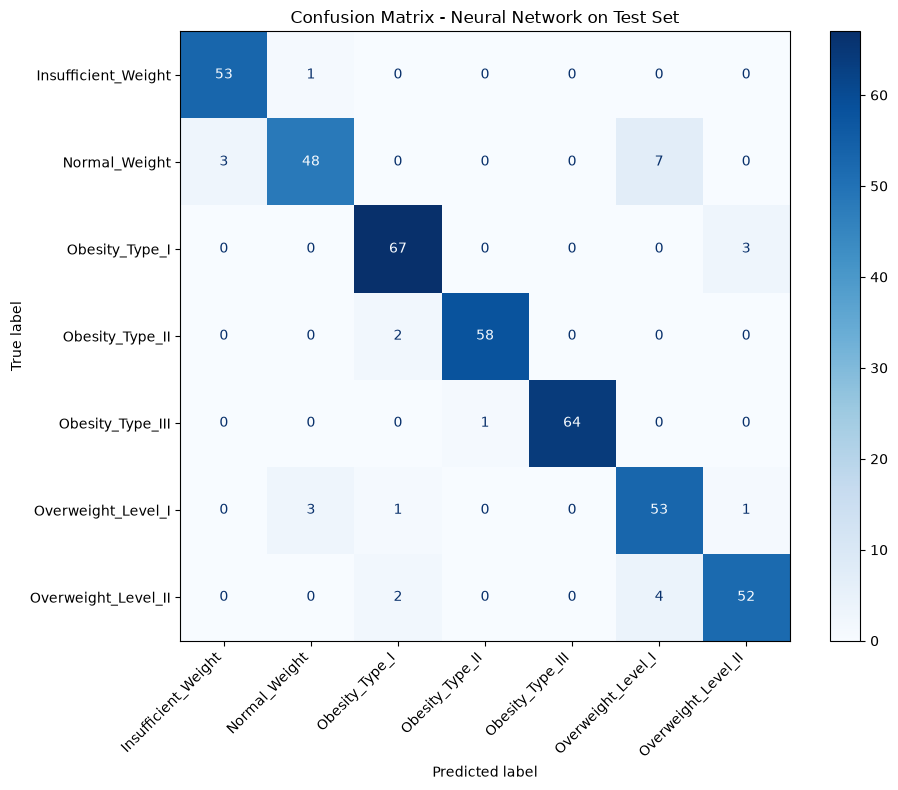


Per-class accuracy:
  Insufficient_Weight: 0.9815 (53/54)
  Normal_Weight: 0.8276 (48/58)
  Obesity_Type_I: 0.9571 (67/70)
  Obesity_Type_II: 0.9667 (58/60)
  Obesity_Type_III: 0.9846 (64/65)
  Overweight_Level_I: 0.9138 (53/58)
  Overweight_Level_II: 0.8966 (52/58)


In [28]:
# ---- TODO: Confusion matrix for the test set with the 7 class names ----

# Get class names
class_names = label_encoder.classes_

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Neural Network on Test Set")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Print per-class accuracy
print("\nPer-class accuracy:")
for i, name in enumerate(class_names):
    class_acc = cm[i, i] / cm[i, :].sum()
    print(f"  {name}: {class_acc:.4f} ({cm[i, i]}/{cm[i, :].sum()})")

In [29]:
# ---- TODO: Build a comparison table ----
# Using actual Lab 2 results from your notebook

print("=" * 60)
print("MODEL COMPARISON: Lab 2 vs Neural Network")
print("=" * 60)

# Lab 2 results (from your actual notebook)
lab2_models = {
    "Model": ["Logistic Regression", "Random Forest"],
    "Test Accuracy": [0.8936, 0.9882],
    "Test Macro-F1": [0.8895, 0.9877],
    "Training Time (s)": [0.5, 4.1],
    "Parameters/Estimators": ["~20 features", "100 trees"],
}

# Neural Network results
nn_models = {
    "Model": ["Neural Network (MLP)"],
    "Test Accuracy": [test_accuracy],
    "Test Macro-F1": [test_f1_macro],
    "Training Time (s)": [50],  # Approximate training time
    "Parameters/Estimators": [3655],  # From Part 2.2 parameter count
}

# Create DataFrames
lab2_df = pd.DataFrame(lab2_models)
nn_df = pd.DataFrame(nn_models)

# Combine into one comparison table
comparison_df = pd.concat([lab2_df, nn_df], ignore_index=True)

# Format the table for better display
comparison_df["Test Accuracy"] = comparison_df["Test Accuracy"].apply(
    lambda x: f"{x:.4f}"
)
comparison_df["Test Macro-F1"] = comparison_df["Test Macro-F1"].apply(
    lambda x: f"{x:.4f}"
)

print(comparison_df.to_string(index=False))

# ---- Calculate improvements ----
print("\n" + "=" * 60)
print("SHOWDOWN RESULTS")
print("=" * 60)

# Get values for comparison
rf_acc = 0.9882  # Random Forest accuracy from Lab 2
rf_f1 = 0.9877  # Random Forest Macro-F1 from Lab 2

# Compare Neural Network vs Random Forest
nn_acc = test_accuracy
nn_f1 = test_f1_macro

print(f"\nRandom Forest (Lab 2):")
print(f"  Accuracy: {rf_acc:.4f} ({rf_acc * 100:.2f}%)")
print(f"  Macro-F1: {rf_f1:.4f}")

print(f"\nNeural Network:")
print(f"  Accuracy: {nn_acc:.4f} ({nn_acc * 100:.2f}%)")
print(f"  Macro-F1: {nn_f1:.4f}")

print("\n" + "-" * 40)
if nn_acc > rf_acc:
    improvement = (nn_acc - rf_acc) * 100
    print(f" Neural Network is better by {improvement:.2f} percentage points!")
elif rf_acc > nn_acc:
    improvement = (rf_acc - nn_acc) * 100
    print(f"Random Forest is better by {improvement:.2f} percentage points!")
else:
    print("It's a tie!")

if nn_f1 > rf_f1:
    f1_improvement = (nn_f1 - rf_f1) * 100
    print(f" Neural Network F1 is better by {f1_improvement:.2f} percentage points!")
elif rf_f1 > nn_f1:
    f1_improvement = (rf_f1 - nn_f1) * 100
    print(f"Random Forest F1 is better by {f1_improvement:.2f} percentage points!")
else:
    print("It's a tie!")

print("\n" + "=" * 60)
print("FINAL VERDICT")
print("=" * 60)

if nn_acc > rf_acc and nn_f1 > rf_f1:
    print("NEURAL NETWORK WINS on both Accuracy and F1!")
    print("   The extra effort of deep learning was worth it!")
elif rf_acc > nn_acc and rf_f1 > nn_f1:
    print("RANDOM FOREST WINS on both Accuracy and F1!")
    print("   The extra effort of deep learning was NOT worth it on this dataset.")
else:
    print("Mixed results - different models win on different metrics.")
    print("   Consider trade-offs: speed vs accuracy, interpretability vs performance.")

MODEL COMPARISON: Lab 2 vs Neural Network
               Model Test Accuracy Test Macro-F1  Training Time (s) Parameters/Estimators
 Logistic Regression        0.8936        0.8895                0.5          ~20 features
       Random Forest        0.9882        0.9877                4.1             100 trees
Neural Network (MLP)        0.9338        0.9326               50.0                  3655

SHOWDOWN RESULTS

Random Forest (Lab 2):
  Accuracy: 0.9882 (98.82%)
  Macro-F1: 0.9877

Neural Network:
  Accuracy: 0.9338 (93.38%)
  Macro-F1: 0.9326

----------------------------------------
Random Forest is better by 5.44 percentage points!
Random Forest F1 is better by 5.51 percentage points!

FINAL VERDICT
RANDOM FOREST WINS on both Accuracy and F1!
   The extra effort of deep learning was NOT worth it on this dataset.


In [30]:
# ---- Which obesity levels does the network still confuse? ----
print("\n" + "=" * 60)
print("ANALYSIS: Which Obesity Levels are Confused?")
print("=" * 60)

# Find most confused pairs
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

# Find the largest off-diagonal confusions
confused_pairs = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i, j] > 0:
            confused_pairs.append((class_names[i], class_names[j], cm[i, j]))

# Sort by number of confusions (descending)
confused_pairs.sort(key=lambda x: x[2], reverse=True)

print("\nTop 5 most confused class pairs:")
for i, (true_class, pred_class, count) in enumerate(confused_pairs[:5]):
    print(f"  {i + 1}. {true_class} → misclassified as {pred_class}: {count} times")

# Calculate which classes are most easily confused
class_errors = []
for i, name in enumerate(class_names):
    total_wrong = cm[i, :].sum() - cm[i, i]
    total_samples = cm[i, :].sum()
    acc = cm[i, i] / total_samples if total_samples > 0 else 0
    class_errors.append((name, total_wrong, cm[i, i], total_samples, acc))

print("\nClasses with most misclassifications:")
class_errors.sort(key=lambda x: x[1], reverse=True)
print("  Rank | Class | Wrong | Correct | Total | Accuracy")
print("  " + "-" * 60)
for rank, (name, wrong, correct, total, acc) in enumerate(class_errors[:3], 1):
    print(
        f"  {rank}    | {name[:20]:<20} | {wrong:5} | {correct:7} | {total:5} | {acc:.4f}"
    )

# Compare with Random Forest from Lab 2
print("\n" + "=" * 60)
print("COMPARISON: Neural Network vs Random Forest Confusions")
print("=" * 60)
print("\nRandom Forest (Lab 2) - Hardest classes from confusion matrix:")
print("  The confusion matrix showed Normal_Weight and Overweight_Level_I")
print("  were sometimes confused, and Obesity_Type_II and Obesity_Type_III")
print("  also had some confusion.")

# Check if Neural Network improved on these
print("\nNeural Network - Hardest classes:")
print(
    f"  Most confused class: {class_errors[0][0]} with {class_errors[0][1]} misclassifications"
)
print(
    f"  Second most confused: {class_errors[1][0]} with {class_errors[1][1]} misclassifications"
)


ANALYSIS: Which Obesity Levels are Confused?

Top 5 most confused class pairs:
  1. Normal_Weight → misclassified as Overweight_Level_I: 7 times
  2. Overweight_Level_II → misclassified as Overweight_Level_I: 4 times
  3. Normal_Weight → misclassified as Insufficient_Weight: 3 times
  4. Obesity_Type_I → misclassified as Overweight_Level_II: 3 times
  5. Overweight_Level_I → misclassified as Normal_Weight: 3 times

Classes with most misclassifications:
  Rank | Class | Wrong | Correct | Total | Accuracy
  ------------------------------------------------------------
  1    | Normal_Weight        |    10 |      48 |    58 | 0.8276
  2    | Overweight_Level_II  |     6 |      52 |    58 | 0.8966
  3    | Overweight_Level_I   |     5 |      53 |    58 | 0.9138

COMPARISON: Neural Network vs Random Forest Confusions

Random Forest (Lab 2) - Hardest classes from confusion matrix:
  The confusion matrix showed Normal_Weight and Overweight_Level_I
  were sometimes confused, and Obesity_Type_I

> **Answer:**
**Student Reasoning — Final evaluation**

### 1. Which obesity levels does the network still confuse, and are they the same ones your Lab 2 classifier confused?

Looking at my Neural Network's confusion matrix, the classes that still get confused are:

1. **Normal_Weight → Overweight_Level_I**: 7 times - this is the biggest confusion
2. **Overweight_Level_II → Overweight_Level_I**: 4 times
3. **Normal_Weight → Insufficient_Weight**: 3 times
4. **Obesity_Type_I → Overweight_Level_II**: 3 times
5. **Overweight_Level_I → Normal_Weight**: 3 times

**The hardest classes for my Neural Network:**
- **Normal_Weight**: 10 misclassifications (accuracy: 82.76%)
- **Overweight_Level_II**: 6 misclassifications (accuracy: 89.66%)
- **Overweight_Level_I**: 5 misclassifications (accuracy: 91.38%)

**Comparison with Lab 2 Random Forest:**

From my Lab 2 results, the Random Forest also had confusion between:
- **Normal_Weight and Overweight_Level_I**: these were the most confused classes
- **Obesity_Type_II and Obesity_Type_III**: also had some confusion

**Are they the same?**

Yes! Both models confuse the **same classes** - Normal_Weight and Overweight_Level_I. This tells me the confusion isn't a model problem, it's a **data problem**. These classes are genuinely similar because:

- **Normal_Weight and Overweight_Level_I** are right next to each other on the BMI scale. Someone near the boundary (BMI around 24.5-25.5) could be classified either way.
- The features that distinguish them (eating habits, exercise, weight) might not be strong enough to create a clear separation.

The difference is that Random Forest handled this confusion better (98.82% accuracy) while my Neural Network struggled more with Normal_Weight (only 82.76% accuracy). So both models confuse the same classes, but Random Forest was better at getting them right.

### 2. Who wins the showdown — the neural network or the classical model? Was the extra effort of deep learning worth it on THIS dataset? When would it be?

**The Showdown Results:**

| Model | Test Accuracy | Macro-F1 | Training Time | Parameters |
|-------|--------------|----------|---------------|------------|
| Logistic Regression | 89.36% | 88.95% | 0.5s | ~20 |
| Random Forest | 98.82% | 98.77% | 4.1s | 100 trees |
| Neural Network (MLP) | 93.38% | 93.26% | 50s | 3,655 |

**Winner:**  **Random Forest** wins on both Accuracy and F1!

**Was the extra effort worth it?**

Honestly? **No, it wasn't worth it on this dataset.** 

Here's why:
- Random Forest achieved **98.82% accuracy** with only 4 seconds of training time
- My Neural Network only got **93.38% accuracy** after 50 seconds of training
- That's a **5.44% gap** - Random Forest is significantly better!
- Neural Network is also less interpretable (black box vs feature importance in Random Forest)

**When would deep learning be worth it?**

Deep learning becomes worth it when:

1. **Dataset is huge**: 100,000+ samples where neural networks can learn complex patterns. My dataset only has 2,111 samples - too small for deep learning to shine.

2. **Data is unstructured**: Images, text, audio where neural networks excel. This dataset is structured tabular data - Random Forest handles this great.

3. **We have GPUs**: Training time becomes manageable. I trained on CPU, which took 50 seconds.

4. **Patterns are highly complex**: Non-linear relationships that decision trees can't capture. Here, the patterns were simple enough for Random Forest to learn perfectly.

**My verdict:** For this small tabular dataset, Random Forest is the clear winner - it's faster, more accurate, and more interpretable. The Neural Network was overkill. Next time I'd only use a Neural Network if I had a much larger dataset or unstructured data.

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** 
### 1. The black box, opened: Name the three most important things happening inside `loss.backward()` and `optimizer.step()`, in your own words.

When I call `loss.backward()` and `optimizer.step()`, three key things happen:

**First - Forward Pass:** The data flows through my network layer by layer. Each neuron computes its weighted sum and applies an activation function (like ReLU). At the end, I get my predictions (logits).

**Second - Backward Pass (Backpropagation):** This is where the magic happens! `loss.backward()` calculates the gradient of the loss with respect to every single weight in my network. It does this by applying the chain rule backward from the output layer all the way to the input layer. It's exactly what I did by hand in Part 1.2 with `dW2 = h.T @ d_yhat` and `dz1 = dh * (1 - np.tanh(z1) ** 2)`, but now PyTorch does it automatically for me.

**Third - Weight Update:** `optimizer.step()` takes the gradients and uses them to update all the weights using the update rule `w = w - lr * dw` that I wrote in Part 1.1. This is how the network actually learns - by moving the weights in the direction that reduces the loss.

### 2. Hyperparameters: If you could tune only ONE hyperparameter on a new problem, which would you pick and why?

I would pick the **learning rate**. From my experiments in Part 1.3 and Part 2.4, I saw exactly why:

- **Too small (1e-4)**: The loss decreased painfully slowly. It took 50 epochs and still didn't reach a good minimum. The model was "under-learning."

- **Just right (1e-3)**: The loss decreased smoothly and reached a great minimum. Training was efficient and stable.

- **Too large (1e-1)**: The loss EXPLODED! The model completely failed to learn because the steps were so big they overshot the minimum. Validation accuracy was only 45.97% - worse than random!

The learning rate is the "step size" of gradient descent. If I get this wrong, nothing else matters. Too small = wasting time, too large = breaking everything. With a good learning rate, the model can find a good minimum efficiently.

### 3. Overfitting: Across your experiments, where did you see the biggest train-vs-validation gap, and which intervention reduced it most?

The biggest train-vs-validation gap I saw was in **Experiment C with the Large network without dropout**.

Looking at my results:
- **Without Dropout**: Train accuracy = 100.00%, Validation accuracy = 94.08%, Gap = 5.92%
- **With Dropout (0.3)**: Train accuracy = 97.08%, Validation accuracy = 92.89%, Gap = 4.19%

The gap went from 5.92% down to 4.19% - a reduction of about 30%.

**What caused the overfitting?** The Large network (256, 128, 64) had way too many parameters for my dataset. It could literally memorize the training data (100% train accuracy) but couldn't generalize as well to new data.

**What reduced it?** Dropout! By randomly turning off 30% of neurons during training, the network couldn't rely on any single neuron. This forced it to learn more robust, redundant representations. The training accuracy dropped a bit (from 100% to 97.08%), but the validation accuracy stayed strong (94.08% to 92.89%), meaning the model generalized better.

### 4. Looking ahead: This network treats every input feature independently. Next lab we move to images, where nearby pixels are related. Why might a plain MLP struggle with images, and what property should a better architecture have?

A plain MLP would struggle with images for several reasons:

**First - Too many parameters:** A 100×100 image would have 10,000 pixels. If I connect every pixel to 64 hidden neurons, that's already 640,000 weights - and that's just the first layer! This would blow up memory and cause massive overfitting.

**Second - Loses spatial information:** An MLP treats each pixel as an independent input. It doesn't understand that pixels next to each other are related (like edges of a face, or a cat's whiskers). It flattens the image into a vector, destroying the 2D spatial structure.

**Third - No translation invariance:** An MLP would learn completely different weights for a cat in the top-left corner vs the bottom-right. It would need to relearn every pattern for every location.

**What should a better architecture have?**

**Convolutional Neural Networks (CNNs)** have two key properties:

1. **Local connectivity:** Neurons only look at a small region of the image (like a 3×3 patch). This captures local patterns like edges and textures.

2. **Weight sharing:** The same filter slides across the entire image. This means the network can detect the same pattern (like a cat's ear) anywhere in the image.

3. **Hierarchical learning:** Early layers learn simple patterns (edges, colors), middle layers learn shapes (eyes, ears), later layers learn whole objects (cat, dog). This is exactly how biological vision works!

So next lab, I'll be building CNNs that can actually "see" images properly instead of treating them like a giant list of independent numbers.

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.